Prédiction de la probabilité de "stress hydrique", le stress hydrique étant considéré ici comme se référant à l'appartenance à la classe "iC-APEX < 0.5", et de l'incertitude associée.

Covariables attendues :
- Raster d'altitude
- Raster de réserve utile (catégoriel)
- Raster de CWB semaine par semaine (le modèle chosira en fonction de la semaine ciblée)
- Données Siclima en csv

Variable cible :
- Valeur continue 0 < p < 1 : probabilité de stress hydrique

Le modèle utilise une loss BCE, AUC-ROC, Accuracy et BCE sont calculées comme métriques d'évaluation. Le split est fait par blocs spatiaux et utilise la méthode Leave-One-Block-Out. L'incertitude associée est prédite parallèlement avec la méthode MC-Dropout. Optuna calcule les meilleurs hyperparamètres avant entraînement.

# 0. IMPORTS

In [1]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import numpy as np
import pandas as pd
import glob
import os
from tqdm import tqdm
import verde as vd

# Geospatial libraries
import rasterio
from rasterio.windows import from_bounds
from rasterio.plot import show
from rasterio.mask import mask as rasterio_mask
import geopandas as gpd
from shapely.geometry import box
from shapely.geometry import Point
from rasterio.transform import from_origin

# Machine Learning
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)  # évite le spam de logs
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import copy

# Additional imports for training
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import copy

# Visualization
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.patch import geos_to_path

# Other
from datetime import datetime, timedelta
from shapely.ops import unary_union

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


# 1. LOAD APEX-VIGNE DATASET

In [2]:
# Load the apex-vigne dataset
df = pd.read_csv('data/data_apex.csv', encoding='latin1', low_memory=False)

print(f"📊 Dataset shape: {df.shape[0]:,} observations × {df.shape[1]} columns")
print(f"\n🔤 Available columns:\n{df.columns.tolist()[:15]}...")

# Display first few rows
df.head(3)

📊 Dataset shape: 46,403 observations × 20 columns

🔤 Available columns:
['id_session', 'date_creation', 'date_maj', 'date_session', 'apex0', 'apex1', 'apex2', 'id_observateur', 'id_parcelle', 'id_stade', 'commentaire', 'device_hardware', 'device_software', 'longitude', 'latitude']...


,id_session,date_creation,date_maj,date_session,apex0,apex1,apex2,id_observateur,id_parcelle,id_stade,commentaire,device_hardware,device_software,longitude,latitude,location,en_parcelle,est_archivee,raison_archive,app_version
0,00020b39-e765-4337-999a-63e1f59aca46,2025-08-19 13:43:38,2025-08-19 13:43:38,2025-07-24,4,37,9,4e5e6f16-d26c-428e-a387-007533fa7be9,5843944e-d9d2-48cc-95c8-8d639807b031,NaN,NaN,iPhone,iOS 18.5,6.132792,45.550099,NaN,1.0,0,NaN,6.2.0
1,00041c61510442e5a64fb3af8ce11e24,2024-05-02 12:16:41,2025-04-18 08:46:16,2024-05-02,35,15,2,70c659af882b42ffb6b9415995434669,2f635c3720504254aebd2687712b0c8b,st-H-57-57,NaN,iPhone,iOS 17.4.1,3.544615,43.533837,NaN,1.0,0,NaN,NaN
2,0007ba68-e4f1-3fbd-82a9-336c7718bb2a,2020-06-25 04:27:02,2025-04-18 08:45:29,2019-07-10,13,31,6,edb6d513-eb76-4ad0-ae8a-0be7770048eb,5241d050-de2c-d5e5-a9f7-59f03c2e12ea,NaN,NaN,samsung SM-A715F,Android 11,NaN,NaN,NaN,0.0,0,NaN,NaN


In [3]:
#Filtrer les observations par date

# Paramètres à modifier
date_debut_str = "2025-07-14"
date_fin_str   = "2025-07-20"

# Filtrage temporel
df['date_session'] = pd.to_datetime(df['date_session'], errors='coerce')
df_filtered = df[(df['date_session'] >= date_debut_str) & (df['date_session'] <= date_fin_str)]

print(f"📅 Période sélectionnée : {date_debut_str} → {date_fin_str}")
print(f"📊 Observations totales  : {len(df):,}")
print(f"📊 Après filtrage        : {len(df_filtered):,} ({len(df_filtered)/len(df)*100:.1f}%)")
print(f"\n📋 Période couverte par les données filtrées :")
print(f"   De : {df_filtered['date_session'].min().date()}")
print(f"   À  : {df_filtered['date_session'].max().date()}")

📅 Période sélectionnée : 2025-07-14 → 2025-07-20
📊 Observations totales  : 46,403
📊 Après filtrage        : 1,257 (2.7%)

📋 Période couverte par les données filtrées :
   De : 2025-07-14
   À  : 2025-07-20


In [4]:
# Conversion en objet spatial
data_sf = (df_filtered
    .assign(
        longitude = pd.to_numeric(df['longitude'].replace("NULL", pd.NA), errors='coerce'),
        latitude  = pd.to_numeric(df['latitude'].replace("NULL", pd.NA),  errors='coerce')
    )
    .dropna(subset=['longitude', 'latitude'])
    .pipe(lambda d: gpd.GeoDataFrame(
        d,
        geometry=gpd.points_from_xy(d['longitude'], d['latitude']),
        crs="EPSG:4326"
    ))
)

In [5]:
# Filtrer les observations dans la zone d'étude
study_zone = gpd.read_file("data/study_zone_viti.gpkg")
data_sf_proj = data_sf.to_crs(study_zone.crs)
data_zone = gpd.sjoin(data_sf_proj, study_zone, how="inner", predicate="within").copy()

# Jointure spatiale observations → mailles SAFRAN pour récupérer l'identifiant 'cell'
coords_safran = pd.read_csv("data/cov/coordonnees_mailles_safran.csv", sep=";")
coords_safran_gdf = gpd.GeoDataFrame(
    coords_safran,
    geometry=gpd.points_from_xy(coords_safran["longitude"], coords_safran["latitude"]),
    crs="EPSG:4326"
).to_crs(study_zone.crs)

# Pour chaque observation, on cherche la maille SAFRAN la plus proche
from shapely.ops import nearest_points
def find_nearest_cell(geom, safran_gdf):
    distances = safran_gdf.geometry.distance(geom)
    return safran_gdf.iloc[distances.idxmin()]["cell"]

data_zone["cell"] = data_zone.geometry.apply(
    lambda g: find_nearest_cell(g, coords_safran_gdf)
)

print(f"✅ Colonne 'cell' ajoutée à data_zone — {data_zone['cell'].nunique()} mailles SAFRAN distinctes")

print(f"📊 Avant filtre zone : {len(data_sf_proj):,} observations")
print(f"📊 Après filtre zone : {len(data_zone):,} observations")
print(f"   Soit {len(data_zone)/len(data_sf_proj)*100:.1f}% des observations retenues")

✅ Colonne 'cell' ajoutée à data_zone — 79 mailles SAFRAN distinctes
📊 Avant filtre zone : 1,247 observations
📊 Après filtre zone : 813 observations
   Soit 65.2% des observations retenues


In [6]:
# Calcul de l'iC-APEX
data_zone['ic_apex'] = (data_zone['apex0'] + 0.5 * data_zone['apex1']) / (
    data_zone['apex0'] + data_zone['apex1'] + data_zone['apex2']
)

# 2. DATA VISUALISATION

In [7]:
# 0. Chargement de la study_zone globale
study_zone_bg = gpd.read_file("data/study_zone.gpkg")
study_zone_bg_wgs = study_zone_bg.to_crs("EPSG:4326")

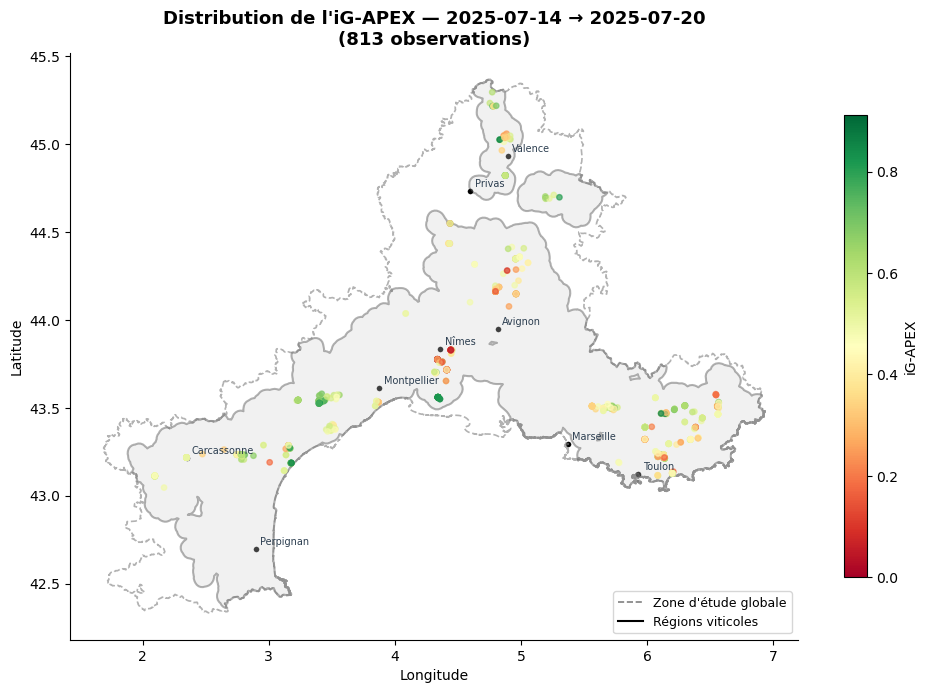

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Reprojection en WGS84 pour affichage cohérent
study_zone_wgs = study_zone.to_crs("EPSG:4326")
data_zone_wgs  = data_zone.to_crs("EPSG:4326")

# Coord villes pour visualisation
villes_data = {
    "Nom": [
        "Perpignan",   # PO
        "Carcassonne",  # Aude
        "Montpellier",  # Hérault
        "Nîmes",        # Gard
        "Avignon",        # Vaucluse
        "Toulon",       # Var
        "Marseille",    # BdR (Bouches-du-Rhône)
        "Privas",       # Ardèche
        "Valence"       # Drôme
    ],
    "Longitude": [2.8956, 2.3522, 3.8767, 4.3601, 4.81667, 5.9306, 5.3698, 4.5980, 4.8924],
    "Latitude": [42.6986, 43.2122, 43.6110, 43.8367, 43.950001, 43.1242, 43.2965, 44.7351, 44.9334],
    "Code_insee": ["66", "11", "34", "30", "84", "83", "13", "07", "26"]
}
df_villes = pd.DataFrame(villes_data)
geometry = [Point(xy) for xy in zip(df_villes["Longitude"], df_villes["Latitude"])]
villes_gdf = gpd.GeoDataFrame(df_villes, geometry=geometry, crs="EPSG:4326")

# Affichage des 9 préfectures
villes_gdf.plot(ax=ax, color="black", markersize=60, marker=".", edgecolor="black", linewidth=0.1, label="Préfectures")

# Ajout des étiquettes de texte (noms des villes)
for x, y, label in zip(villes_gdf.geometry.x, villes_gdf.geometry.y, villes_gdf["Nom"]):
    ax.annotate(
        label, 
        xy=(x, y), 
        xytext=(3, 3),
        textcoords="offset points", 
        fontsize=7, 
        weight="normal",
        color="#2c3e50"
    )
    
# Contour de la zone d'étude
study_zone_wgs.plot(
    ax=ax,
    facecolor='lightgrey',
    edgecolor='black',
    linewidth=1.5,
    alpha=0.3
)

# Contours study_zone complète
study_zone_bg_wgs.plot(
    ax=ax,
    facecolor="none",
    edgecolor="grey",
    linewidth=1.2,
    linestyle="--",
    alpha=0.6,
)

# Points colorés par iG-APEX
data_zone_wgs.plot(
    ax=ax,
    column='ic_apex',
    cmap='RdYlGn',
    markersize=15,
    alpha=0.7,
    legend=True,
    legend_kwds={'label': 'iG-APEX', 'shrink': 0.6}
)

# Légende commune
legend_elements = [
    Line2D(
        [0],
        [0],
        color="grey",
        linewidth=1.2,
        linestyle="--",
        label="Zone d'étude globale",
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=1.5,
        linestyle="-",
        label="Régions viticoles",
    ),
]

ax.set_title(
    f"Distribution de l'iG-APEX — {date_debut_str} → {date_fin_str}\n"
    f"({len(data_zone_wgs):,} observations)",
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(handles=legend_elements, fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()

# 3. LOAD STUDY ZONE (GRID)

In [9]:
grid = gpd.read_file("data/study_zone_viti_grid.gpkg")
print(f"📐 Cellules de grille totales         : {grid.shape[0]:,}")

📐 Cellules de grille totales         : 36,377


# 4. RASTERS

In [10]:
from datetime import datetime, timedelta
import glob
import rasterio
import numpy as np

# --- 1. Configuration des dates pour le CWB ---
# Assure-toi que date_debut_str est bien définie plus haut (ex: "2025-07-20")
date_debut = datetime.strptime(date_debut_str, "%Y-%m-%d")
date_cwb = date_debut - timedelta(days=1)
date_cwb_str = date_cwb.strftime("%Y-%m-%d") 

# --- 2. Construction dynamique des chemins des fichiers ---
# Chemins pour l'altitude (alt) et la réserve utile (ru)
subfolders = ['alt', 'ru', 'pente', 'exp']
raster_files = []
for sub in subfolders:
    files = sorted(glob.glob(f'data/cov/rasters/{sub}/*.tif'))
    raster_files.extend(files)

# Chemin dynamique pour le CWB basé sur la date calculée
cwb_raster_path = f"data/cov/rasters/cwb/CWB_1km_{date_cwb_str}.tif"
cwb_file = glob.glob(cwb_raster_path)

if not cwb_file:
    print(f"⚠️ Attention : Le raster CWB pour la date {date_cwb_str} est introuvable à l'adresse {cwb_raster_path}")
else:
    raster_files.extend(cwb_file)

# --- 3. Fonction d'extraction spatiale (Rasterio) ---
def extract_raster_value(gdf, raster_path):
    with rasterio.open(raster_path) as src:
        # Repérage du centre de chaque cellule géométrique
        centroids = gdf.geometry.centroid
        coords = [(c.x, c.y) for c in centroids]
        
        # Échantillonnage de la valeur du pixel sous le centroïde
        sampled_values = [v[0] for v in src.sample(coords)]
        
        # Gestion des valeurs de NoData du raster
        if src.nodata is not None:
            sampled_values = [np.nan if v == src.nodata else v for v in sampled_values]
            
    return sampled_values

for f in raster_files:
    with rasterio.open(f) as src:
        res = abs(src.transform[0])
        print(f"   {f}")
        print(f"      Dimensions : {src.width} × {src.height} pixels")
        print(f"      Résolution : {res:.0f} m\n")

   data/cov/rasters/alt\altitude_study_zone.tif
      Dimensions : 424 × 337 pixels
      Résolution : 1000 m

   data/cov/rasters/ru\ru_raster.tif
      Dimensions : 425 × 336 pixels
      Résolution : 1000 m

   data/cov/rasters/pente\slope.tif
      Dimensions : 409 × 335 pixels
      Résolution : 1000 m

   data/cov/rasters/exp\exposure.tif
      Dimensions : 409 × 335 pixels
      Résolution : 1000 m

   data/cov/rasters/cwb/CWB_1km_2025-07-13.tif
      Dimensions : 405 × 336 pixels
      Résolution : 1000 m



# 5. VISUALISATION OF COVARIABLES

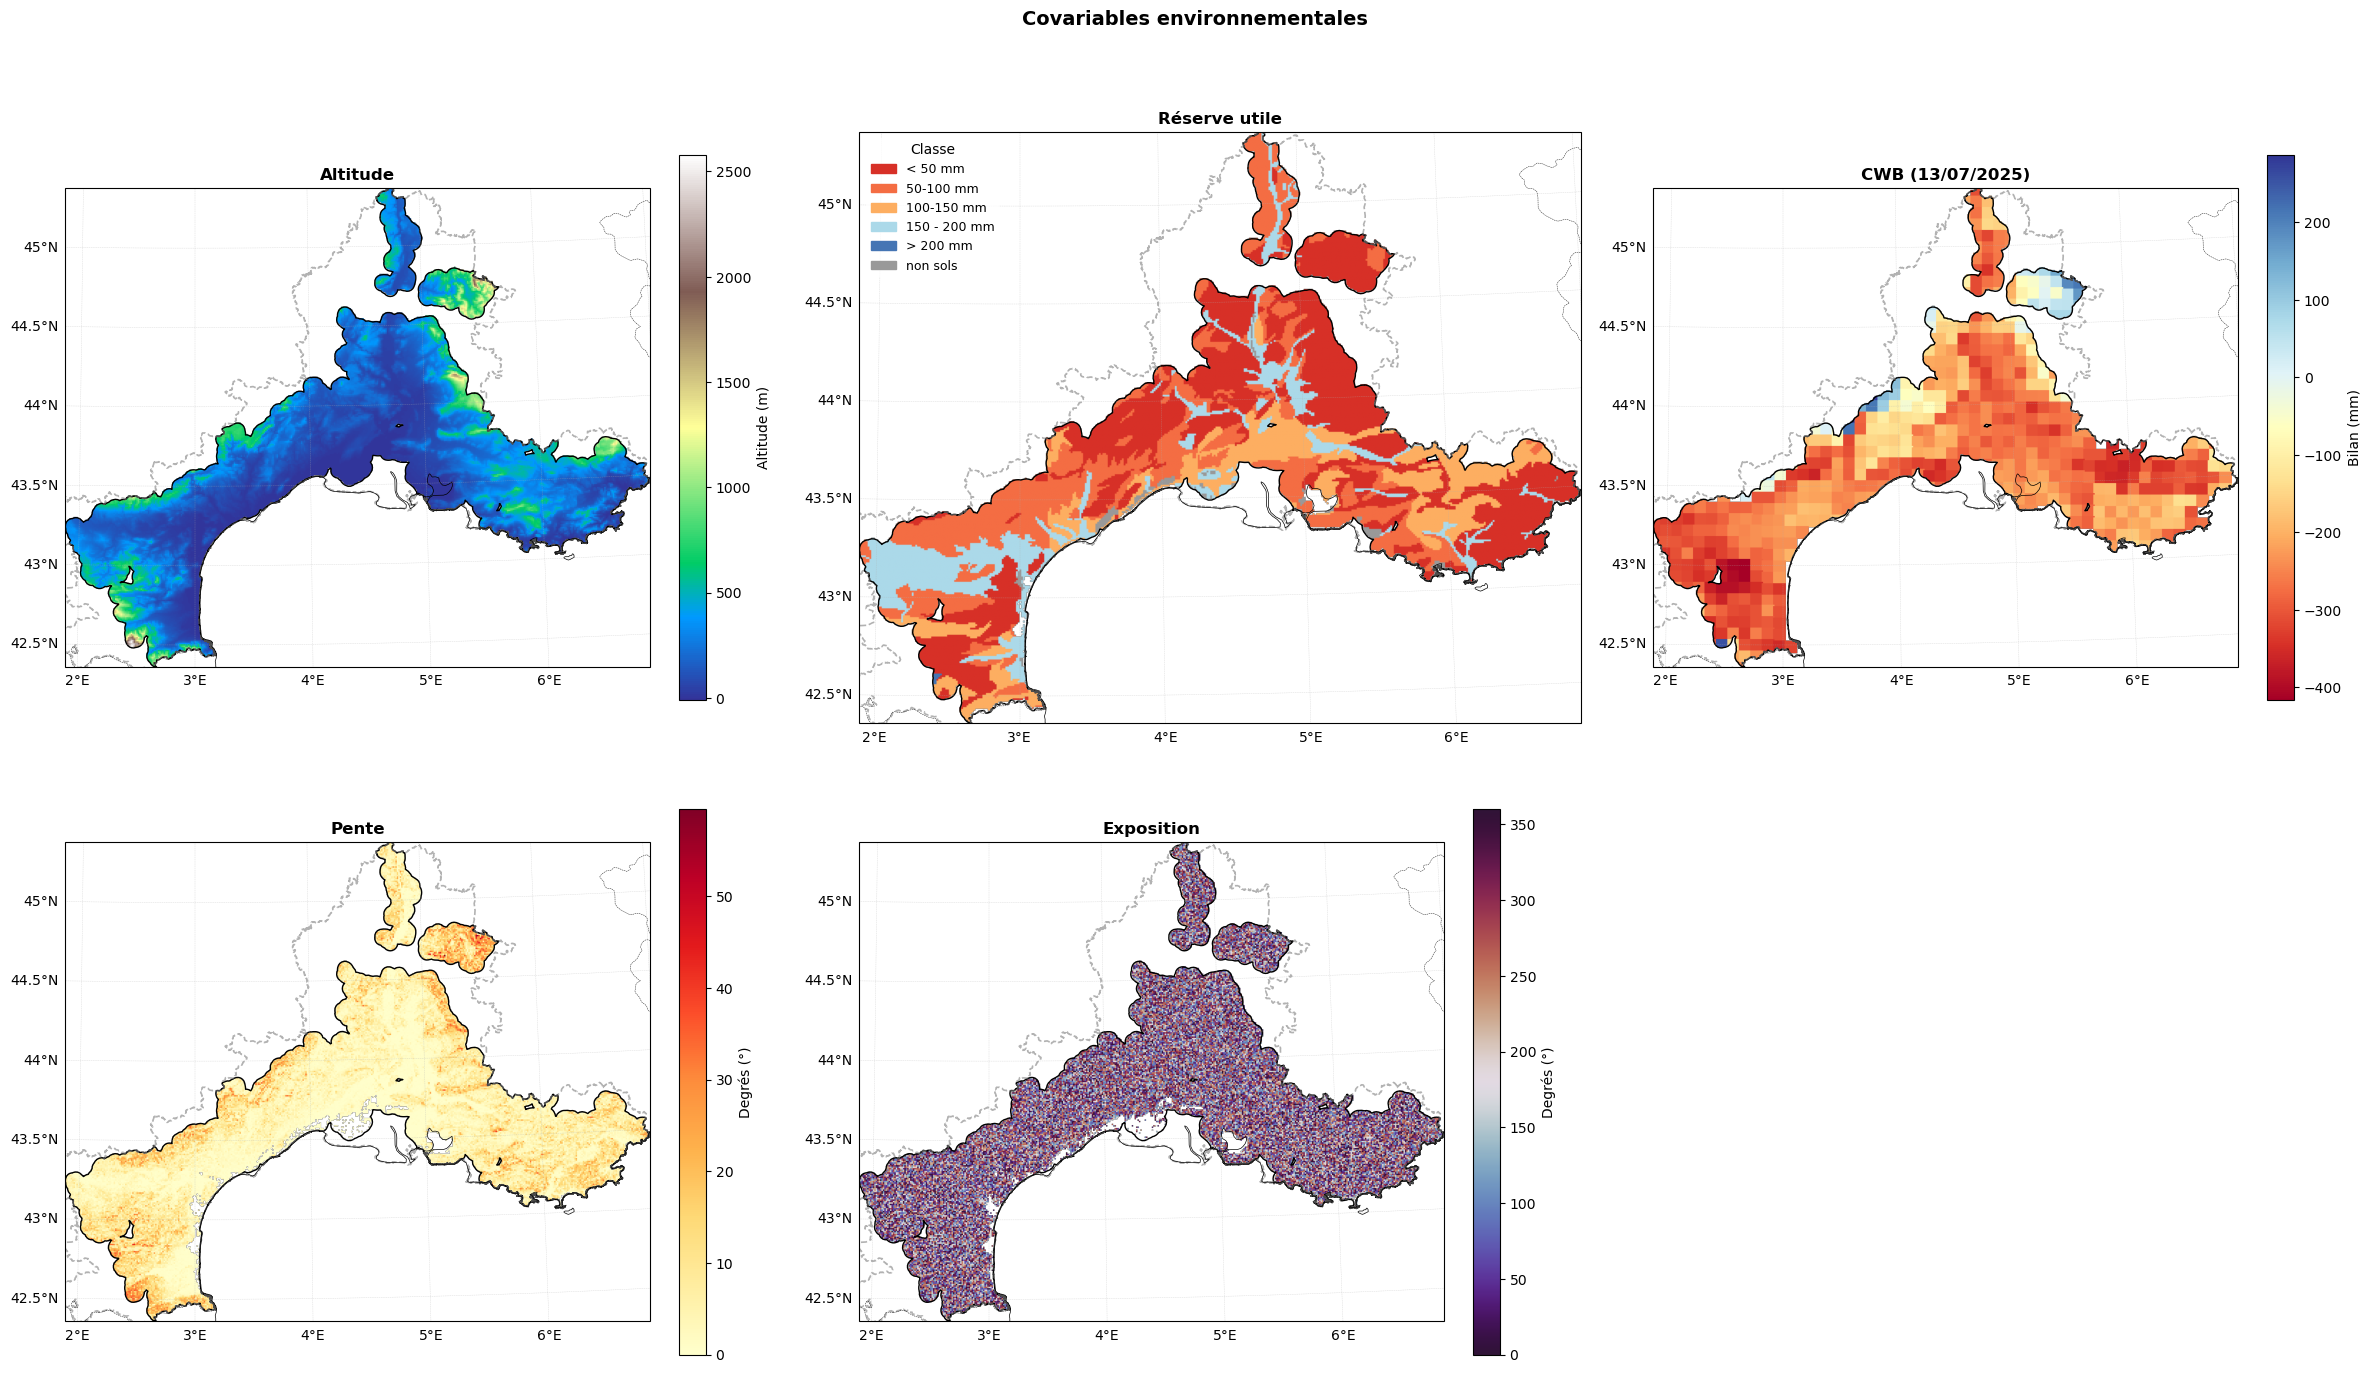

In [11]:
# --- 1. Configuration Réserve Utile ---
ru_labels = {1: "< 50 mm", 2: "50-100 mm", 3: "100-150 mm", 4: "150 - 200 mm", 5: "> 200 mm", 9: "non sols"}
ru_colors = ['#d73027', '#f46d43', '#fdae61', '#abd9e9', '#4575b4', '#999999']
ru_cmap = ListedColormap(ru_colors)
ru_bounds = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 9.5] 
ru_norm = BoundaryNorm(ru_bounds, ru_cmap.N)

geoms = [study_zone.union_all()]


# --- 3. Définition des variables à afficher ---
# On passe à 3 variables en incluant la CWB
variables_to_plot = [
    ('data/cov/rasters/alt/altitude_study_zone.tif', 'Altitude', 'Altitude (m)', 'terrain', None, None),
    ('data/cov/rasters/ru/ru_raster.tif', 'Réserve utile', 'Classe', ru_cmap, ru_norm, ru_labels),
    (cwb_raster_path, f'CWB ({date_cwb.strftime("%d/%m/%Y")})', 'Bilan (mm)', 'RdYlBu', None, None),
    ('data/cov/rasters/pente/slope.tif', 'Pente', 'Degrés (°)', 'YlOrRd', None, None),
    ('data/cov/rasters/exp/exposure.tif', 'Exposition', 'Degrés (°)', 'twilight_shifted', None, None)
]


# --- 4. Tracé des graphiques ---
# On passe à 1 ligne et 3 colonnes (1, 3)
fig, axes = plt.subplots(2, 3, figsize=(24, 14), subplot_kw={'projection': ccrs.epsg(2154)})

# Aplatir la grille 2×3 en liste et masquer la 6ème case (vide)
axes_flat = axes.flatten()
axes_flat[-1].set_visible(False)

for ax, (filepath, title, unit, cmap, norm, labels) in zip(axes_flat, variables_to_plot):
    
    # Sécurité : Vérifier si le fichier CWB existe avant d'essayer de l'ouvrir
    if not os.path.exists(filepath):
        ax.set_title(f"{title}\n(Fichier introuvable)", fontsize=12, color='red', fontweight='bold')
        ax.axis('off')
        continue

    with rasterio.open(filepath) as src:
        out_image, out_transform = rasterio_mask(src, geoms, crop=True, nodata=np.nan)
        data = out_image[0].astype(np.float32)
        
        img_height, img_width = data.shape
        left, bottom = out_transform * (0, img_height)
        right, top = out_transform * (img_width, 0)
        extent = [left, right, bottom, top]
        
        nodata = src.nodata

    if nodata is not None:
        data = np.ma.masked_where((data == nodata) | np.isnan(data) | ~np.isfinite(data), data)
    else:
        data = np.ma.masked_where((data <= -9999) | (data == 0) | np.isnan(data) | ~np.isfinite(data), data)

    ax.set_facecolor('none')
    ax.set_extent([study_zone.total_bounds[0], study_zone.total_bounds[2],
                   study_zone.total_bounds[1], study_zone.total_bounds[3]], 
                 crs=ccrs.epsg(2154))

    im = ax.imshow(data, extent=extent, origin='upper', cmap=cmap, norm=norm,
                   transform=ccrs.epsg(2154))
    
    study_zone.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1, transform=ccrs.epsg(2154))
    study_zone_bg.plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle='--')

    # Gestion des légendes (La CWB tombera ici dans labels is None)
    if labels is None:
        cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.04)
        cbar.set_label(unit, fontsize=10)
    else:
        legend_patches = [
            mpatches.Patch(color=ru_colors[i], label=labels[val])
            for i, val in enumerate([1, 2, 3, 4, 5, 9])
        ]
        ax.legend(handles=legend_patches, title=unit, loc='upper left', 
                  frameon=True, facecolor='white', edgecolor='none', fontsize=9)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Covariables environnementales', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 6. PREPARE TRAINING DATA

In [12]:
for i, raster in enumerate(raster_files, 1):
    with rasterio.open(raster) as src:
        raster_resolution = abs(src.transform[0])
        raster_transform = src.transform
        raster_crs = src.crs

        print(f"{i:2d}. {os.path.basename(raster)}. Résolution : {raster_resolution:.0f} m. CRS : {raster_crs}.")

 1. altitude_study_zone.tif. Résolution : 1000 m. CRS : EPSG:2154.
 2. ru_raster.tif. Résolution : 1000 m. CRS : EPSG:2154.
 3. slope.tif. Résolution : 1000 m. CRS : EPSG:2154.
 4. exposure.tif. Résolution : 1000 m. CRS : EPSG:2154.
 5. CWB_1km_2025-07-13.tif. Résolution : 1000 m. CRS : EPSG:2154.


In [13]:
# Calcul de l'iC-APEX
data_zone = data_zone.copy()
data_zone['date_session'] = pd.to_datetime(data_zone['date_session']).dt.date
data_zone['ic_apex'] = (data_zone['apex0'] + data_zone['apex1'] * 0.5) / \
                       (data_zone['apex0'] + data_zone['apex1'] + data_zone['apex2'])

print(f"📍 Observations brutes      : {len(df):,}")
print(f"📍 Après nettoyage spatial  : {len(data_sf):,}")
print(f"📍 Dans la zone d'étude     : {len(data_zone):,}")
print(f"\n📋 Aperçu iG-APEX :")
print(data_zone['ic_apex'].describe().round(3))

📍 Observations brutes      : 46,403
📍 Après nettoyage spatial  : 1,247
📍 Dans la zone d'étude     : 813

📋 Aperçu iG-APEX :
count    813.000
mean       0.461
std        0.182
min        0.000
25%        0.350
50%        0.480
75%        0.560
max        0.911
Name: ic_apex, dtype: float64


In [14]:
# Coordonnées des centroïdes de la grille en Lambert
grid_proj = grid.to_crs("EPSG:2154")

# Jointure spatiale grid_proj → mailles SAFRAN pour récupérer l'identifiant 'cell'
coords_safran = pd.read_csv("data/cov/coordonnees_mailles_safran.csv", sep=";")
coords_safran_gdf = gpd.GeoDataFrame(
    coords_safran,
    geometry=gpd.points_from_xy(coords_safran["longitude"], coords_safran["latitude"]),
    crs="EPSG:4326"
).to_crs("EPSG:2154")

# Pour chaque cellule de la grille, on cherche la maille SAFRAN la plus proche
from sklearn.neighbors import BallTree
import numpy as np

# Coordonnées des centroïdes de la grille
grid_coords = np.array([
    (geom.centroid.x, geom.centroid.y) for geom in grid_proj.geometry
])

# Coordonnées des points SAFRAN
safran_coords = np.array([
    (geom.x, geom.y) for geom in coords_safran_gdf.geometry
])

# Recherche du point SAFRAN le plus proche pour chaque cellule
tree = BallTree(safran_coords, metric="euclidean")
indices = tree.query(grid_coords, k=1, return_distance=False).flatten()

grid_proj = grid_proj.copy()
grid_proj["cell"] = coords_safran_gdf.iloc[indices]["cell"].values

print(f"✅ Colonne 'cell' ajoutée à grid_proj — {grid_proj['cell'].nunique()} mailles SAFRAN distinctes")
print(grid_proj[["cell"]].head(3))


centroids = [(geom.centroid.x, geom.centroid.y) for geom in grid_proj.geometry]
num_cells = len(grid_proj)
num_variables = len(raster_files)

print(f"📍 Nombre de cellules : {num_cells:,}")
print(f"📁 Nombre de variables : {num_variables}")

# Tenseur X — valeurs environnementales
X_tensor = torch.zeros((num_cells, num_variables), dtype=torch.float32)

print("\n🌡️ Extraction des valeurs des covariables...")
for var_idx, filepath in enumerate(tqdm(raster_files, desc="Processing rasters")):
    with rasterio.open(filepath) as src:
        nodata = src.nodata
        values = np.array([val[0] for val in src.sample(centroids)], dtype=np.float32)
        if nodata is not None:
            values[values == nodata] = np.nan
        X_tensor[:, var_idx] = torch.tensor(values, dtype=torch.float32)

print(f"\n✅ Tenseur X créé !")

✅ Colonne 'cell' ajoutée à grid_proj — 638 mailles SAFRAN distinctes
   cell
0  9257
1  9257
2  9257
📍 Nombre de cellules : 36,377
📁 Nombre de variables : 5

🌡️ Extraction des valeurs des covariables...


Processing rasters: 100%|████████████████████████████████████████████████████████████████| 5/5 [00:04<00:00,  1.18it/s]


✅ Tenseur X créé !


In [15]:
import ast

# Chargement unique du CSV SICLIMA (une seule fois, pas dans la boucle !)
year = pd.to_datetime(date_debut_str).year
df_sic = pd.read_csv(f"data/cov/cov_siclima_{year}.csv", engine='python')
df_sic = df_sic.set_index("cell")  # indexation par cell pour accès rapide

N_COV_SICLIMA = 16

def load_siclima_vector(cell: int, date_obs: str) -> np.ndarray:
    if cell not in df_sic.index:
        return np.full(N_COV_SICLIMA, np.nan, dtype=np.float32)
    if date_obs not in df_sic.columns:
        return np.full(N_COV_SICLIMA, np.nan, dtype=np.float32)
    valeur = df_sic.loc[cell, date_obs]
    if isinstance(valeur, str):
        valeur = ast.literal_eval(valeur)
    return np.array(valeur, dtype=np.float32)

print("🌿 Extraction des covariables SICLIMA...")
siclima_values = np.array([
    load_siclima_vector(cell=row["cell"], date_obs=date_debut_str)
    for _, row in tqdm(grid_proj.iterrows(), total=len(grid_proj), desc="SICLIMA")
], dtype=np.float32)

X_siclima = torch.tensor(siclima_values, dtype=torch.float32)
X_tensor = torch.cat([X_tensor, X_siclima], dim=1)
num_variables = X_tensor.shape[1]

print(f"✅ SICLIMA ajouté — X_tensor shape : {X_tensor.shape}")

🌿 Extraction des covariables SICLIMA...


SICLIMA: 100%|████████████████████████████████████████████████████████████████| 36377/36377 [00:02<00:00, 13411.22it/s]

✅ SICLIMA ajouté — X_tensor shape : torch.Size([36377, 21])


In [16]:
# Index de la colonne RU dans all_raster_files
ru_idx = next(i for i, f in enumerate(raster_files) if 'ru' in f.lower())

# Valeurs RU brutes
ru_values = X_tensor[:, ru_idx].numpy()

# Classes attendues (9 = non-sol traité séparément)
ru_classes = [1, 2, 3, 4, 5, 9]

# One-hot encoding
ru_onehot = np.zeros((num_cells, len(ru_classes)), dtype=np.float32)
for j, cls in enumerate(ru_classes):
    ru_onehot[:, j] = (ru_values == cls).astype(np.float32)

# Remplacement de la colonne RU par les colonnes one-hot
X_np = X_tensor.numpy()
X_np_without_ru = np.delete(X_np, ru_idx, axis=1)
X_tensor = torch.tensor(
    np.concatenate([X_np_without_ru, ru_onehot], axis=1),
    dtype=torch.float32
)

# Mise à jour du nombre de variables
num_variables = X_tensor.shape[1]

print(f"✅ RU encodée en one-hot ({len(ru_classes)} classes) et tenseur X mis à jour")
print(f"   X (covariables) : {X_tensor.shape}")

✅ RU encodée en one-hot (6 classes) et tenseur X mis à jour
   X (covariables) : torch.Size([36377, 26])


In [17]:
# Seuil de binarisation iC-APEX
IC_APEX_THRESHOLD = 0.5  # >= seuil → présence (1), < seuil → absence (0)

# Tenseur y — iC-APEX binarisé par cellule de grille
print("\n🔢 Construction du tenseur y (présence/absence par case)...")
data_zone_proj = data_zone.to_crs("EPSG:2154")
grid_with_idx  = grid_proj.copy()
grid_with_idx['cell_idx'] = range(num_cells)

# Jointure spatiale observations -> cellules
joined = gpd.sjoin(data_zone_proj[['ic_apex', 'geometry']],
                   grid_with_idx[['cell_idx', 'geometry']],
                   how='left', predicate='within')

# Moyenne de l'iC-APEX par cellule puis binarisation
ic_mean   = joined.groupby('cell_idx')['ic_apex'].mean()
ic_mean   = ic_mean.dropna()
ic_binary = (ic_mean >= IC_APEX_THRESHOLD).astype(float)

# Tenseur y binaire
y_tensor = torch.zeros((num_cells,), dtype=torch.float32)
y_tensor[ic_binary.index] = torch.tensor(ic_binary.values, dtype=torch.float32)

# Masque — cellules observées uniquement
observed_mask = torch.zeros(num_cells, dtype=torch.bool)
observed_mask[ic_binary.index] = True

# Exclure les non-sols (RU == 9)
nonsoil_mask  = torch.tensor(ru_values == 9)
observed_mask = observed_mask & ~nonsoil_mask

print(f"\n✅ Tenseur y créé !")
print(f"   Seuil iC-APEX                     : {IC_APEX_THRESHOLD}")
print(f"   y (présence/absence par cellule)  : {y_tensor.shape}")
print(f"   Présences  (1)                    : {(y_tensor[observed_mask] == 1).sum().item():,}")
print(f"   Absences   (0)                    : {(y_tensor[observed_mask] == 0).sum().item():,}")
print(f"   Ratio présences                   : {(y_tensor[observed_mask] == 1).sum().item() / observed_mask.sum().item()*100:.1f}%")
print(f"   Cellules non-sol exclues          : {nonsoil_mask.sum().item():,}")
print(f"   Cellules masquées (non observées) : {(~observed_mask).sum().item():,} / {num_cells:,}")


🔢 Construction du tenseur y (présence/absence par case)...

✅ Tenseur y créé !
   Seuil iC-APEX                     : 0.5
   y (présence/absence par cellule)  : torch.Size([36377])
   Présences  (1)                    : 88
   Absences   (0)                    : 94
   Ratio présences                   : 48.4%
   Cellules non-sol exclues          : 367
   Cellules masquées (non observées) : 36,195 / 36,377


## 7. DATA QUALITY CHECK

In [18]:
# Check for missing values
nan_mask = torch.isnan(X_tensor)
rows_with_nan = nan_mask.any(dim=1).sum().item()
total_nan = nan_mask.sum().item()

print(f"📈 Feature Statistics:")
for i, fname in enumerate(raster_files):
    var_name = fname.replace('data/cov/rasters/', '').replace('.tif', '')
    values = X_tensor[:, i]
    valid_values = values[~torch.isnan(values)]
    if len(valid_values) == 0:
        print(f"   {var_name}: ⚠️ aucune valeur valide")
    else:
        print(f"   {var_name}: min={valid_values.min():.1f}, max={valid_values.max():.1f}, mean={valid_values.mean():.1f}")

print(f"\n⚠️  Missing Values:")
print(f"   Cellules avec NaN : {rows_with_nan:,} / {num_cells:,} ({100*rows_with_nan/num_cells:.1f}%)")
print(f"   Total NaN         : {total_nan:,}")

📈 Feature Statistics:
   alt\altitude_study_zone: min=-11.1, max=2578.6, mean=273.8
   ru\ru_raster: min=0.0, max=59.5, mean=6.6
   pente\slope: min=0.0, max=360.0, mean=179.7
   exp\exposure: min=-416.8, max=357.2, mean=-232.6
   cwb/CWB_1km_2025-07-13: min=484936.0, max=589800.5, mean=547350.8

⚠️  Missing Values:
   Cellules avec NaN : 2,904 / 36,377 (8.0%)
   Total NaN         : 5,601


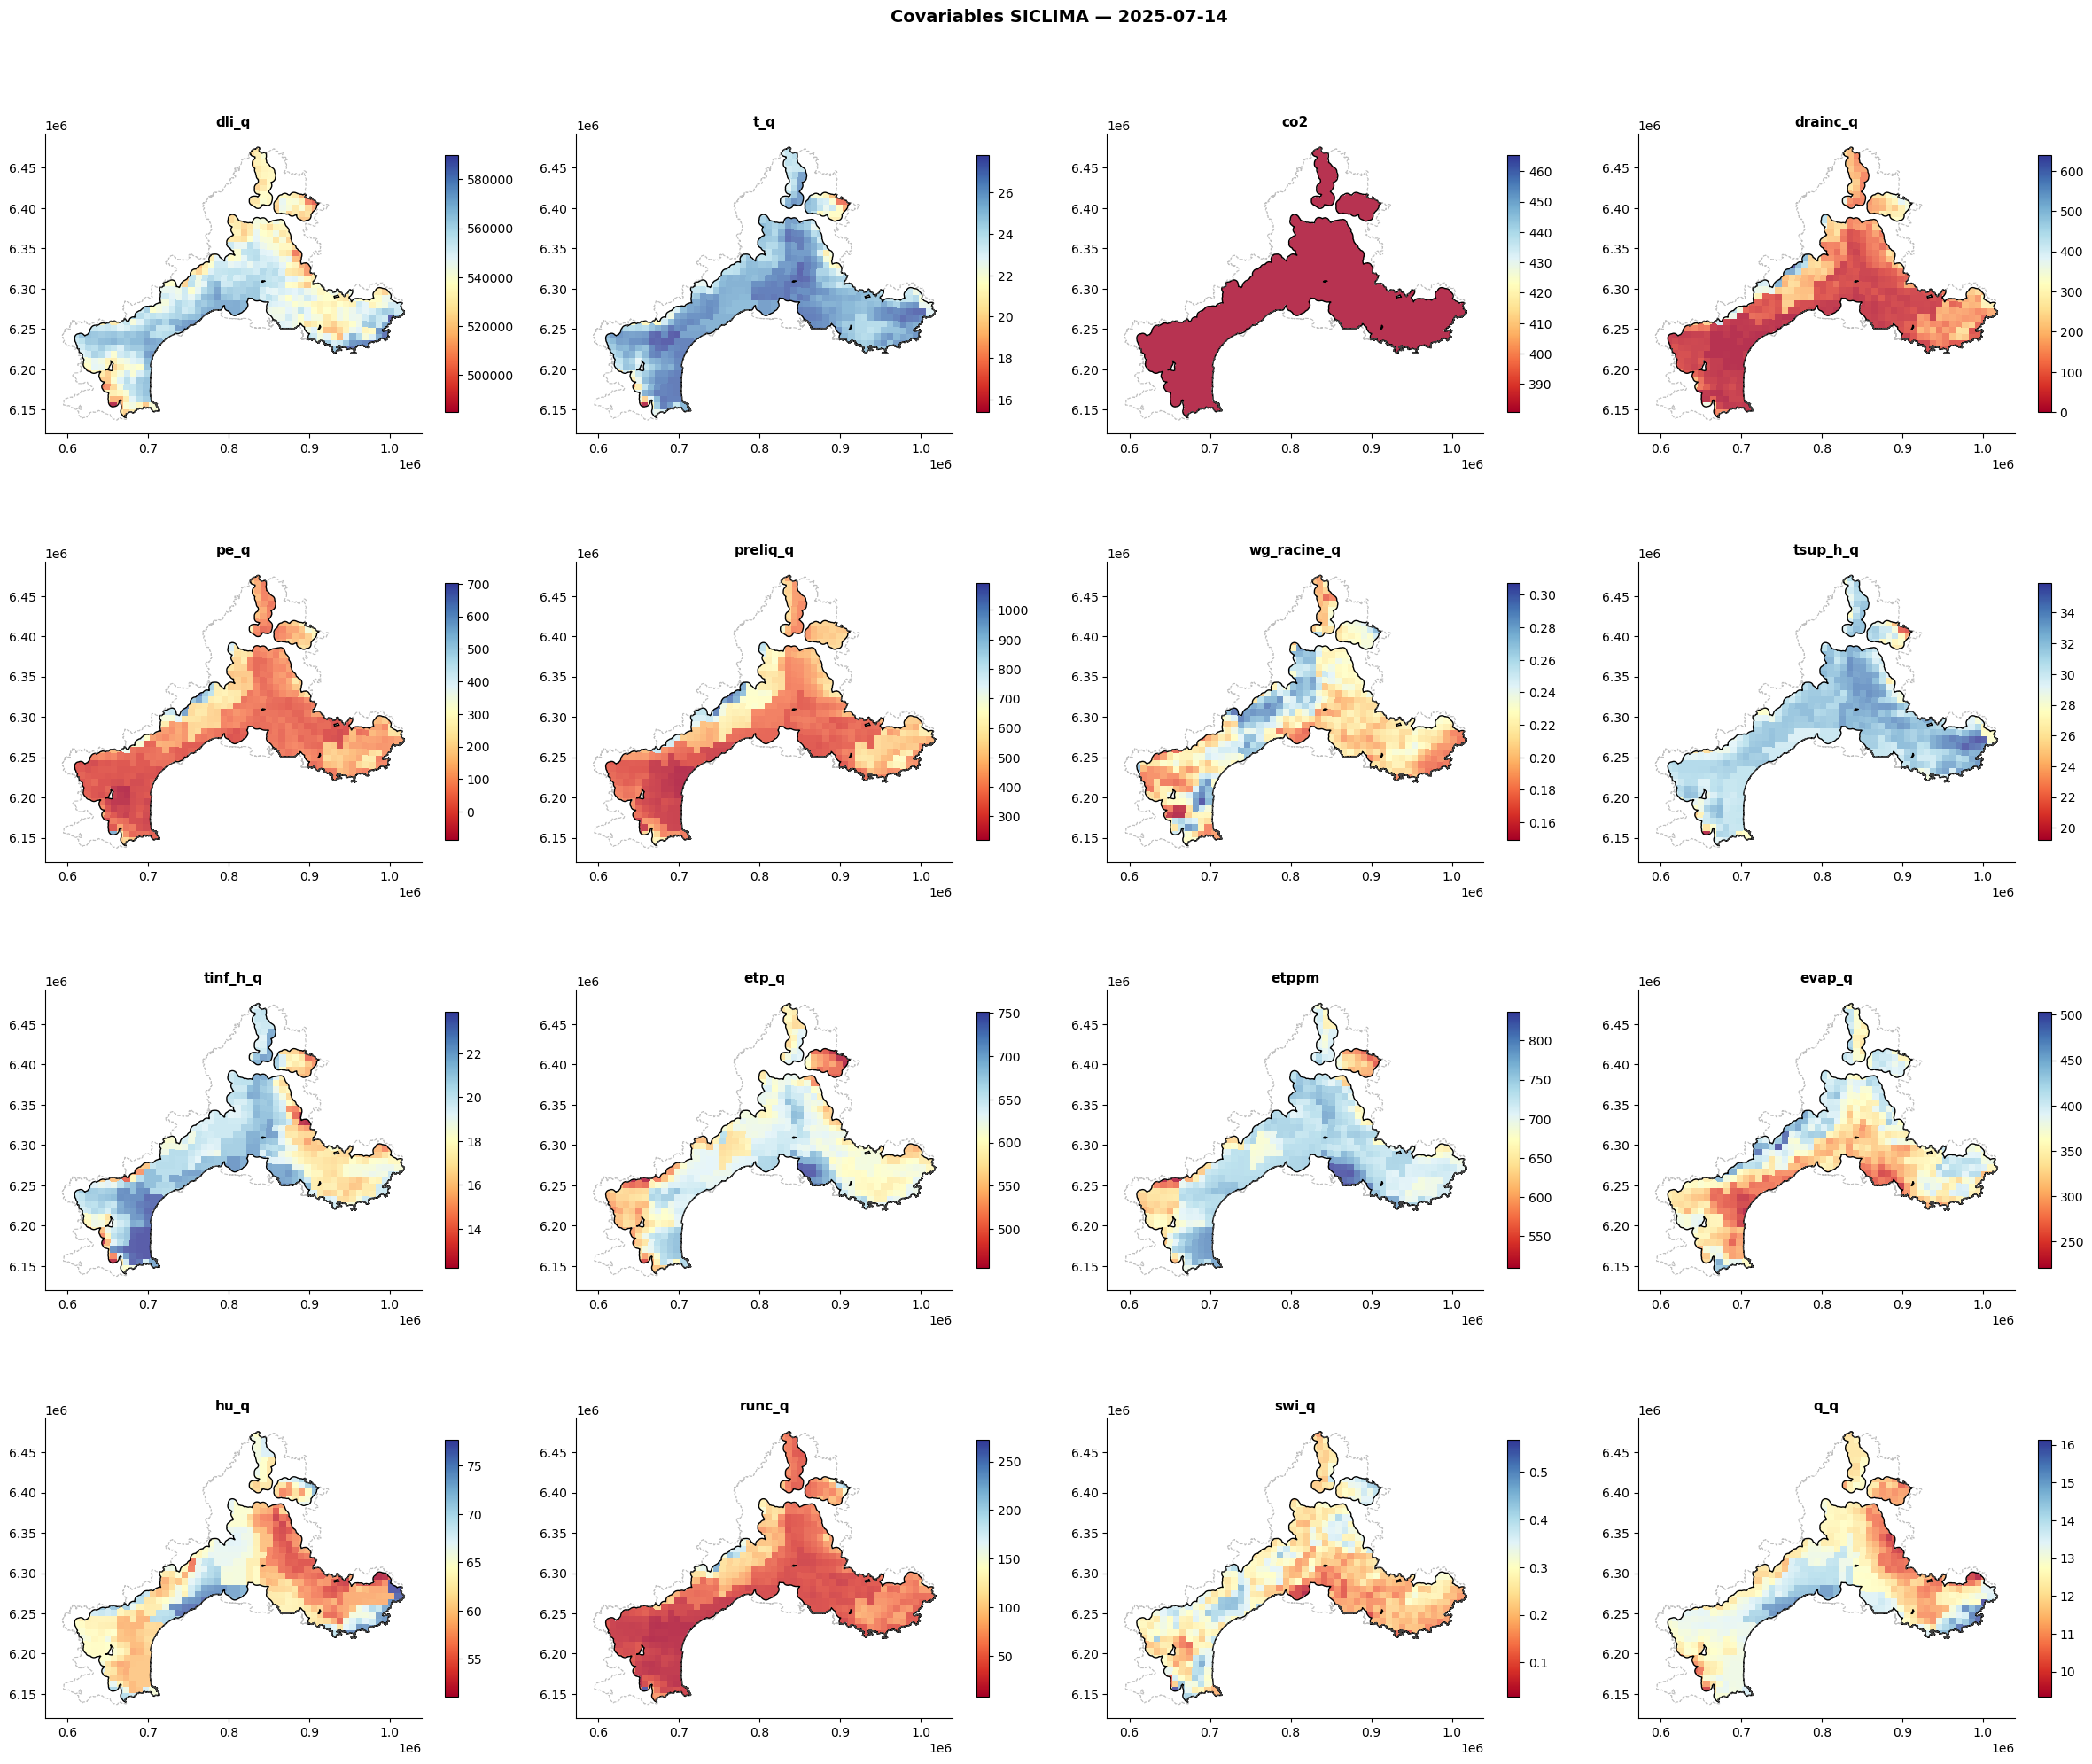

In [19]:
# --- Visualisation des covariables SICLIMA ---
# Utilise df_sic et siclima_values déjà en mémoire (pas de rechargement CSV)

COVARIABLES = ["dli_q", "t_q", "co2", "drainc_q", "pe_q", "preliq_q", "wg_racine_q",
               "tsup_h_q", "tinf_h_q", "etp_q", "etppm", "evap_q", "hu_q", "runc_q", "swi_q", "q_q"]

# Associer chaque covariable à sa colonne dans siclima_values (déjà calculé)
grid_siclima = grid_proj.copy()
for i, cov_name in enumerate(COVARIABLES):
    grid_siclima[cov_name] = siclima_values[:, i]

# Affichage en grille 4×4
study_zone_proj    = study_zone.to_crs("EPSG:2154")
study_zone_bg_proj = study_zone_bg.to_crs("EPSG:2154")

fig, axes = plt.subplots(4, 4, figsize=(24, 20))

for i, (ax, cov_name) in enumerate(zip(axes.flatten(), COVARIABLES)):
    grid_siclima.dropna(subset=[cov_name]).plot(
        ax=ax, column=cov_name, cmap="RdYlBu",
        legend=True, alpha=0.8,
        legend_kwds={"shrink": 0.6}
    )
    study_zone_proj.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)
    study_zone_bg_proj.plot(ax=ax, facecolor="none", edgecolor="grey",
                            linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_title(cov_name, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle(f"Covariables SICLIMA — {date_debut_str}", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 8. SPATIAL SPLIT FOR TEST/TRAINING

In [20]:
# --- 1. Extraction des coordonnées ---
obs_indices = np.where(observed_mask.numpy())[0]
grid_wgs84  = grid.to_crs("EPSG:4326")
coords_obs  = np.array([
    (grid_wgs84.geometry.iloc[i].centroid.x,
     grid_wgs84.geometry.iloc[i].centroid.y)
    for i in obs_indices
])

# Tenseurs sur cellules observées uniquement
X_obs = X_tensor[observed_mask]
y_obs = y_tensor[observed_mask]

print(f"📍 Cellules observées : {len(obs_indices)}")


# --- 2. Création de la grille spatiale manuelle (5x5) ---
lon = coords_obs[:, 0]
lat = coords_obs[:, 1]

# On découpe l'amplitude des lons/lats en 5 intervalles réguliers
lon_bins = np.linspace(lon.min(), lon.max(), 6)
lat_bins = np.linspace(lat.min(), lat.max(), 6)

# On attribue à chaque point son index de case (de 0 à 4)
lon_id = np.digitize(lon, lon_bins[:-1]) - 1
lat_id = np.digitize(lat, lat_bins[:-1]) - 1

# On combine les ID (ex: lon_id=2 et lat_id=3 devient le groupe unique "2_3")
# On utilise np.unique(..., return_inverse=True) pour transformer ça en entiers propres (0, 1, 2...)
spatial_groups_str = [f"{lon}_{lat}" for lon, lat in zip(lon_id, lat_id)]
_, spatial_groups = np.unique(spatial_groups_str, return_inverse=True)


# --- 3. Validation Croisée avec LeaveOneGroupOut ---
logo = LeaveOneGroupOut()
# Le nombre de splits est égal au nombre de groupes spatiaux uniques occupés
N_SPLITS = logo.get_n_splits(groups=spatial_groups)


# --- 4. Construction des datasets par fold ---
x_trains, y_trains = [], []
x_vals,   y_vals   = [], []

# # .split() prend nos groupes spatiaux en argument
# for ind_train, ind_val in logo.split(X_obs, y_obs, groups=spatial_groups):
#     x_trains.append(X_obs[ind_train])
#     y_trains.append(y_obs[ind_train])
#     x_vals.append(X_obs[ind_val])
#     y_vals.append(y_obs[ind_val])


# # --- 5. Affichage des Folds (LOO Spatial avec scikit-learn) ---
# print(f"✅ {N_SPLITS} folds créés via Scikit-Learn (Mode Leave-One-Block-Out) :")
# for i in range(N_SPLITS):
#     n_train = len(x_trains[i])
#     n_val   = len(x_vals[i])
#     n_pos_t = y_trains[i].sum().item()
#     n_pos_v = y_vals[i].sum().item()
#     print(f"   Fold {i+1:02d} — Train : {n_train:03d} ({n_pos_t:.0f} présences) "
#           f"| Val : {n_val:02d} ({n_pos_v:.0f} présences)")

📍 Cellules observées : 182


VALIDATION ALEATOIRE (ESSAI)

In [22]:
# --- 3b. Sélection aléatoire d'observations comme validation ---
rng = np.random.default_rng(seed=42)

n_obs    = len(X_obs)
n_val    = max(1, int(n_obs * 0.2))  # 20% en validation

val_idx   = rng.choice(n_obs, size=n_val, replace=False)
train_idx = np.setdiff1d(np.arange(n_obs), val_idx)

print(f"🎲 Split aléatoire : {len(train_idx)} train / {len(val_idx)} val "
      f"({n_val/n_obs*100:.0f}% validation)")

x_trains = [X_obs[train_idx]]
y_trains = [y_obs[train_idx]]
x_vals   = [X_obs[val_idx]]
y_vals   = [y_obs[val_idx]]

🎲 Split aléatoire : 146 train / 36 val (20% validation)


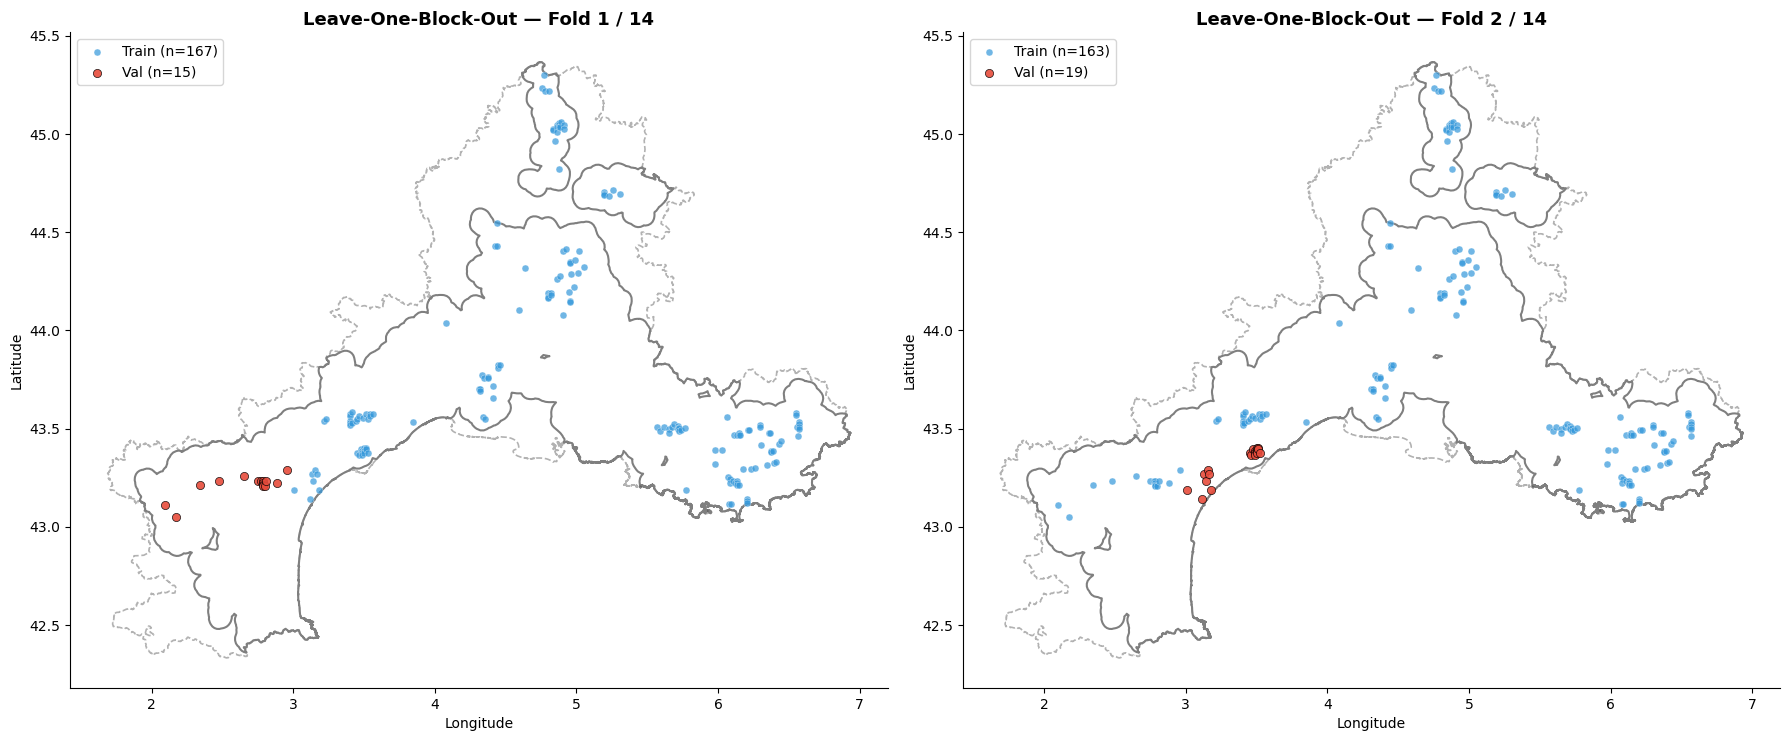

In [55]:
# 1. Configuration de la figure avec 2 sous-graphiques côte à côte (1 ligne, 2 colonnes)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
study_zone_wgs = study_zone.to_crs("EPSG:4326")

# 2. On récupère le générateur de splits de scikit-learn
logo_viz = LeaveOneGroupOut().split(X_obs, y_obs, groups=spatial_groups)

# On va boucler sur les folds et dessiner uniquement les deux premiers
for fold_idx, (ind_train, ind_val) in enumerate(logo_viz):
    if fold_idx > 1:  # On s'arrête après le fold index 1 (donc le 2ème fold)
        break
        
    ax = axes[fold_idx]  # Sélection de l'axe (0 pour le Fold 1, 1 pour le Fold 2)
    
    # Extraction des coordonnées pour ce fold spécifique
    train_coords = coords_obs[ind_train]
    val_coords   = coords_obs[ind_val]
    
    # Dessin du contour de la zone d'étude
    study_zone_wgs.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5, alpha=0.5)
    study_zone_bg_wgs.plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)

    # Affichage des points d'entraînement (Bleu)
    ax.scatter(train_coords[:, 0], train_coords[:, 1],
               c='#3498db', s=25, alpha=0.7, 
               label=f'Train (n={len(train_coords)})',
               edgecolor='white', linewidth=0.3)
    
    # Affichage des points de validation (Rouge)
    ax.scatter(val_coords[:, 0], val_coords[:, 1],
               c='#e74c3c', s=35, alpha=0.9, 
               label=f'Val (n={len(val_coords)})',
               edgecolor='black', linewidth=0.5)  # Légèrement accentué pour les petits blocs
    
    # Personnalisation de l'axe courant
    ax.set_title(f'Leave-One-Block-Out — Fold {fold_idx + 1} / {N_SPLITS}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend(fontsize=10, loc='upper left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
# Ajustement global et affichage
plt.tight_layout()
plt.show()

SPLIT ALEATOIRE

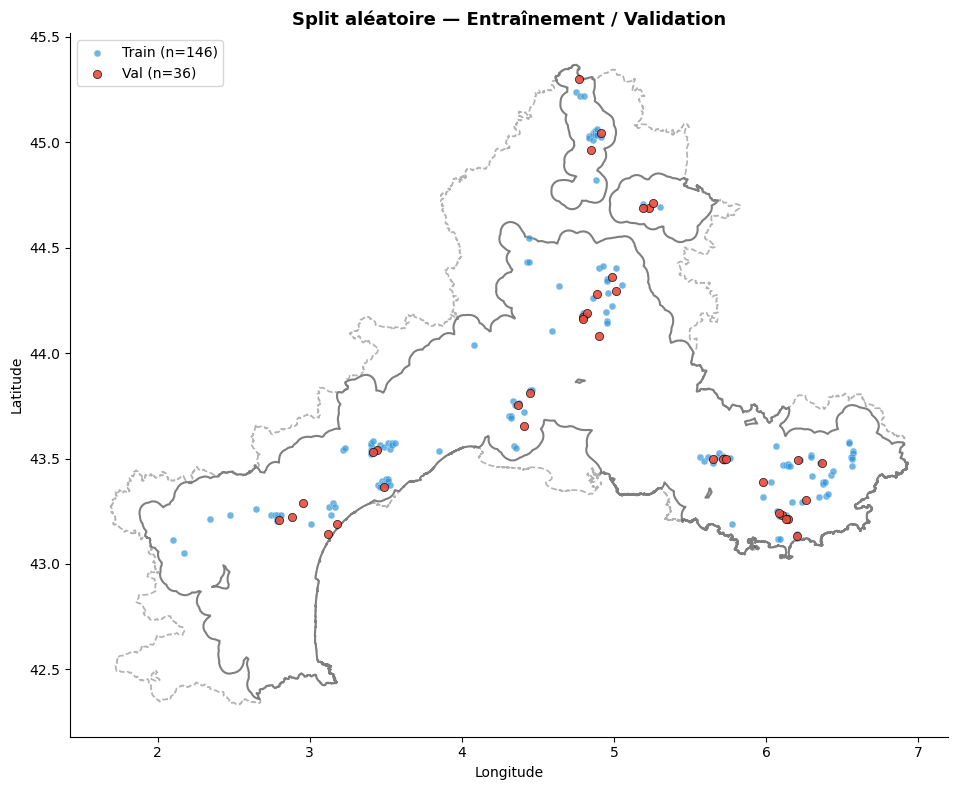

In [56]:
# 1. Configuration de la figure (1 seul graphique)
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
study_zone_wgs = study_zone.to_crs("EPSG:4326")

# 2. Récupération des coordonnées train/val
train_coords = coords_obs[train_idx]
val_coords   = coords_obs[val_idx]

# 3. Contours de la zone d'étude
study_zone_wgs.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5, alpha=0.5)
study_zone_bg_wgs.plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)

# 4. Points d'entraînement (Bleu)
ax.scatter(train_coords[:, 0], train_coords[:, 1],
           c='#3498db', s=25, alpha=0.7,
           label=f'Train (n={len(train_coords)})',
           edgecolor='white', linewidth=0.3)

# 5. Points de validation (Rouge)
ax.scatter(val_coords[:, 0], val_coords[:, 1],
           c='#e74c3c', s=35, alpha=0.9,
           label=f'Val (n={len(val_coords)})',
           edgecolor='black', linewidth=0.5)

# 6. Personnalisation
ax.set_title('Split aléatoire — Entraînement / Validation',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(fontsize=10, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 9. MODEL TRAINING

In [57]:
# --- 1. Configuration des Hyperparamètres ---
class Args:
    def __init__(self):
        self.learning_rate = 0.0001
        self.epoch         = 50
        self.hidden_nbr    = 1
        self.weight_decay  = 1e-4
        # Ajusté à 8 (ou 4) car vos Folds ont des tailles de données réduites (138 à 180 lignes en Train)
        self.batch_size    = 8  

args = Args()

# --- 2. Allocation du Device (CPU/GPU) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device : {device}")

# --- 3. Paramètres structurels du Réseau de Neurones ---
# Dynamique : s'adapte automatiquement au nombre de covariables présentes dans X_obs
input_size  = X_obs.shape[1]  
output_size = 1               # 1 seule sortie car c'est une probabilité de présence (Classification binaire)
hidden_size = 32

print(f"📐 Architecture — Entrée : {input_size} neurones (features) | Sortie : {output_size} neurones")
print(f"🔄 Nombre de Folds à entraîner au total : {N_SPLITS}")

# Nombre de colonnes continues (tout sauf les one-hot RU)
n_onehot     = len(ru_classes)  # 6
n_continuous = X_obs.shape[1] - n_onehot

🖥️  Device : cuda
📐 Architecture — Entrée : 26 neurones (features) | Sortie : 1 neurones
🔄 Nombre de Folds à entraîner au total : 14


In [58]:
class mlp_model(nn.Module):
    def __init__(self, input_size, hidden_size, hidden_nbr, dropout_p=0.2):
        super(mlp_model, self).__init__()
        self.dropout_p = dropout_p
        layers = []

        # Première couche cachée
        layers += [
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(p=dropout_p)
        ]
        
        # Couches cachées intermédiaires
        for _ in range(hidden_nbr - 1):
            layers += [
                nn.Linear(hidden_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.ReLU(),
                nn.Dropout(p=dropout_p)
            ]
            
        # Couche de sortie (Logits bruts, le sigmoid est appliqué après)
        layers.append(nn.Linear(hidden_size, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

    def mc_forward(self, x, n_samples=50):
        """
        Garde UNIQUEMENT le dropout actif pour l'inférence Monte Carlo,
        tout en figeant le BatchNorm pour éviter les biais sur petits effectifs.
        """
        self.eval()  # Par défaut, on passe tout en mode évaluation (fise le BatchNorm)
        
        # Force spécifiquement les couches Dropout à RESTER en mode train
        for m in self.modules():
            if isinstance(m, nn.Dropout):
                m.train()
                
        with torch.no_grad():
            # Gestion de la dimension si x ne contient qu'une seule ligne (ex: n_samples sur 1 cellule)
            preds = []
            for _ in range(n_samples):
                out = torch.sigmoid(self.network(x)).squeeze()
                # Sécurité : si out est un scalaire (0D), on le transforme en tenseur 1D
                if out.dim() == 0:
                    out = out.unsqueeze(0)
                preds.append(out)
                
            preds = torch.stack(preds, dim=0)  # Shape finale : (n_samples, n_cells)
            
        return preds

In [59]:
def predict_with_uncertainty(model, X_tensor, device, n_samples=100):
    """
    Prédit les probabilités de présence et l'incertitude (écart-type)
    via Monte Carlo Dropout, en sécurisant les couches BatchNorm.
    """
    model.eval()  # On fige le modèle (notamment le BatchNorm)
    
    # On force uniquement le Dropout à s'activer pour l'inférence MC
    for m in model.modules():
        if isinstance(m, torch.nn.Dropout):
            m.train()
            
    preds = []
    # On pousse les données sur le device une seule fois pour optimiser la mémoire
    X_tensor = X_tensor.to(device)
    
    with torch.no_grad():
        for _ in range(n_samples):
            logits = model(X_tensor).squeeze()
            
            # Sécurité : si X_tensor n'a qu'une ligne, logits devient un scalaire 0D
            if logits.dim() == 0:
                logits = logits.unsqueeze(0)
                
            # Application de la fonction Sigmoid pour obtenir des probabilités [0, 1]
            preds.append(torch.sigmoid(logits).cpu())
            
    # Empilement des échantillons : shape (n_samples, n_cells)
    preds = torch.stack(preds)  
    
    # Calcul de la moyenne (probabilité finale) et de l'écart-type (incertitude)
    mean_pred = preds.mean(dim=0)
    std_pred = preds.std(dim=0)
    
    return mean_pred, std_pred

In [60]:
def train_model(X_train, y_train, X_val, y_val, args, hidden_size=128, device="cpu"):
    """
    Entraînement d'un MLP pour la classification (Présence/Absence).
    Adapté pour le Leave-One-Block-Out (sécurisé contre les tailles de batch unitaires).

    Returns:
        dict : modèle, historique des pertes, meilleur val_loss
    """
    # DataLoader pour l'entraînement
    train_dataset = TensorDataset(X_train, y_train)
    train_loader  = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, drop_last=True)

    # Modèle, loss, optimizer
    input_size  = X_train.shape[1]
    model       = mlp_model(input_size, hidden_size, args.hidden_nbr).to(device)
    criterion   = nn.BCEWithLogitsLoss()
    optimizer   = optim.AdamW(
        model.parameters(),
        lr=args.learning_rate,
        weight_decay=args.weight_decay
    )

    # Historique
    train_losses = []
    val_losses   = []
    best_val_loss    = float('inf')
    best_model_state = None

    print("🚀 Entraînement...")
    print("=" * 60)

    for epoch in tqdm(range(args.epoch), desc="Training"):

        # --- 1. Phase train ---
        model.train()
        total_train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            
            outputs = model(batch_X).squeeze(-1) # On squeeze uniquement la dimension des features (-1)
            
            # Sécurité si le batch n'a qu'un seul élément
            if outputs.dim() == 0:
                outputs = outputs.unsqueeze(0)
                
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # --- 2. Phase validation ---
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val.to(device)).squeeze(-1)
            
            # Sécurité si le jeu de validation du bloc actuel est minuscule (ex: n_val = 1)
            if val_outputs.dim() == 0:
                val_outputs = val_outputs.unsqueeze(0)
                
            val_loss = criterion(val_outputs, y_val.to(device)).item()
        val_losses.append(val_loss)

        # --- 3. Logs et Sauvegarde ---
        # Log tous les 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"   Epoch {epoch+1:3d} | Train BCE: {avg_train_loss:.4f} | Val BCE: {val_loss:.4f}")

        # Sauvegarde du meilleur modèle sur la perte de validation
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_model_state = copy.deepcopy(model.state_dict())

    # Rechargement du meilleur état
    if best_model_state is None:
        print("⚠️  Aucun meilleur modèle sauvegardé — val_loss était NaN/inf à chaque epoch")
        print("   Vérification des tenseurs d'entrée :")
        print(f"   X_train NaN : {torch.isnan(X_train).sum().item()}")
        print(f"   y_train NaN : {torch.isnan(y_train).sum().item()}")
        return None
    
    model.load_state_dict(best_model_state)

    # ✅ Calcul de l'AUC sur le meilleur modèle
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val.to(device)).squeeze(-1)
        if val_logits.dim() == 0:
            val_logits = val_logits.unsqueeze(0)
        val_probs = torch.sigmoid(val_logits).cpu().numpy()

    y_val_np = y_val.numpy()

    # Sécurité : roc_auc_score plante si une seule classe est présente dans y_val
    if len(np.unique(y_val_np)) < 2:
        print("⚠️  Val set contient une seule classe — AUC indéfinie, fold ignoré.")
        return None

    val_auc = roc_auc_score(y_val_np, val_probs)

    print("=" * 60)
    print(f"✅ Entraînement terminé ! Meilleur Val BCE : {best_val_loss:.4f} | Val AUC : {val_auc:.4f}")

    return {
        "model"        : model,
        "train_losses" : train_losses,
        "val_losses"   : val_losses,
        "best_val_loss": best_val_loss,
        "val_auc"      : val_auc
    }

### OPTUNA

In [61]:
def objective(trial):
    # Espace de recherche des hyperparamètres
    lr           = trial.suggest_float("lr",           1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)
    hidden_size  = trial.suggest_categorical("hidden_size", [32, 64, 128])
    hidden_nbr   = trial.suggest_int("hidden_nbr", 1, 3)
    dropout_p    = trial.suggest_float("dropout_p", 0.1, 0.4)
    batch_size   = trial.suggest_categorical("batch_size", [8, 16, 32])

    val_aucs = []

    for fold_idx in range(N_SPLITS):
        X_train_raw = x_trains[fold_idx]
        X_val_raw   = x_vals[fold_idx]
        y_train_f   = y_trains[fold_idx]
        y_val_f     = y_vals[fold_idx]

        # Nettoyage NaN
        train_nan_mask = torch.isnan(X_train_raw).any(dim=1)
        val_nan_mask   = torch.isnan(X_val_raw).any(dim=1)
        X_train_clean  = X_train_raw[~train_nan_mask]
        y_train_clean  = y_train_f[~train_nan_mask]
        X_val_clean    = X_val_raw[~val_nan_mask]
        y_val_clean    = y_val_f[~val_nan_mask]

        if len(X_val_clean) == 0 or len(X_train_clean) == 0:
            continue

        # Normalisation
        scaler = StandardScaler()
        X_train_cont = scaler.fit_transform(X_train_clean[:, :n_continuous].numpy())
        X_val_cont   = scaler.transform(X_val_clean[:, :n_continuous].numpy())

        X_train_t = torch.tensor(
            np.concatenate([X_train_cont, X_train_clean[:, n_continuous:].numpy()], axis=1),
            dtype=torch.float32
        )
        X_val_t = torch.tensor(
            np.concatenate([X_val_cont, X_val_clean[:, n_continuous:].numpy()], axis=1),
            dtype=torch.float32
        )

        # Modèle
        model_t    = mlp_model(X_train_t.shape[1], hidden_size, hidden_nbr, dropout_p).to(device)
        criterion  = nn.BCEWithLogitsLoss()
        optimizer  = optim.AdamW(model_t.parameters(), lr=lr, weight_decay=weight_decay)
        loader     = DataLoader(TensorDataset(X_train_t, y_train_clean),
                                batch_size=batch_size, shuffle=True, drop_last=True)

        # Entraînement rapide (moins d'epochs pour la recherche)
        best_val = float("inf")
        for epoch in range(50):
            model_t.train()
            for bX, by in loader:
                bX, by = bX.to(device), by.to(device)
                optimizer.zero_grad()
                out = model_t(bX).squeeze(-1)
                if out.dim() == 0:
                    out = out.unsqueeze(0)
                loss = criterion(out, by)
                loss.backward()
                optimizer.step()

            model_t.eval()
            with torch.no_grad():
                val_logits = model_t(X_val_t.to(device)).squeeze(-1)
                val_probs  = torch.sigmoid(val_logits).cpu().numpy()
                auc = roc_auc_score(y_val_clean.numpy(), val_probs)
            val_aucs.append(auc)

        return np.mean(val_aucs) if val_aucs else 0.0

In [62]:
study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n✅ Meilleurs hyperparamètres trouvés :")
for k, v in study.best_params.items():
    print(f"   {k:20s} : {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


✅ Meilleurs hyperparamètres trouvés :
   lr                   : 0.0005977799565497162
   weight_decay         : 4.597345806598628e-05
   hidden_size          : 128
   hidden_nbr           : 2
   dropout_p            : 0.2868210212543576
   batch_size           : 32


In [63]:
best_params = study.best_params

class Args:
    def __init__(self):
        self.learning_rate = best_params["lr"]
        self.epoch         = 50  # plus d'epochs pour l'entraînement final
        self.hidden_nbr    = best_params["hidden_nbr"]
        self.weight_decay  = best_params["weight_decay"]
        self.batch_size    = best_params["batch_size"]

args        = Args()
hidden_size = best_params["hidden_size"]
dropout_p   = best_params["dropout_p"]

### ENTRAINEMENT

In [64]:
all_results = []

for fold_idx in range(N_SPLITS):
    print(f"\n{'='*60}")
    print(f"🔁 FOLD {fold_idx + 1} / {N_SPLITS} (Leave-One-Block-Out)")
    print(f"{'='*60}")

    # Preprocessing du fold
    X_train_raw = x_trains[fold_idx]
    X_val_raw   = x_vals[fold_idx]
    y_train_f   = y_trains[fold_idx]
    y_val_f     = y_vals[fold_idx]

    # Suppression NaN
    train_nan_mask = torch.isnan(X_train_raw).any(dim=1)
    val_nan_mask   = torch.isnan(X_val_raw).any(dim=1)
    
    X_train_clean  = X_train_raw[~train_nan_mask]
    y_train_clean  = y_train_f[~train_nan_mask]
    X_val_clean    = X_val_raw[~val_nan_mask]
    y_val_clean    = y_val_f[~val_nan_mask]

    # ⚠️ SÉCURITÉ CRITIQUE : Vérifier si le jeu de validation ou d'entraînement est vide après nettoyage
    if len(X_val_clean) == 0:
        print(f"⏩ Fold {fold_idx + 1} ignoré : Aucune donnée de validation valide après suppression des NaNs.")
        continue
    if len(X_train_clean) == 0:
        print(f"⏩ Fold {fold_idx + 1} ignoré : Aucune donnée d'entraînement valide après suppression des NaNs.")
        continue

    # Normalisation (fit sur train uniquement)
    scaler_fold = StandardScaler()
    X_train_cont_scaled = scaler_fold.fit_transform(X_train_clean[:, :n_continuous].numpy())
    X_val_cont_scaled   = scaler_fold.transform(X_val_clean[:, :n_continuous].numpy())

    X_train_tensor_f = torch.tensor(
        np.concatenate([X_train_cont_scaled, X_train_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )
    X_val_tensor_f = torch.tensor(
        np.concatenate([X_val_cont_scaled, X_val_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )

    # Entraînement
    fold_results = train_model(
        X_train     = X_train_tensor_f,
        y_train     = y_train_clean,
        X_val       = X_val_tensor_f,
        y_val       = y_val_clean,
        args        = args,
        hidden_size = hidden_size,
        device      = device
    )

    if fold_results is not None:
        all_results.append({
            "fold"        : fold_idx + 1,
            "results"     : fold_results,
            "scaler"      : scaler_fold,
            "val_loss"    : fold_results["best_val_loss"],
            "val_auc"  : fold_results["val_auc"]
        })

# --- Résumé de la Cross-Validation Spatiale ---
print(f"\n📊 RÉSUMÉ CROSS-VALIDATION SPATIALE")
print("=" * 60)
if len(all_results) > 0:
    val_losses = [r["val_loss"] for r in all_results]
    val_aucs   = [r["val_auc"]  for r in all_results]
    print(f"   Nombre de folds validés : {len(all_results)} / {N_SPLITS}")
    print(f"   AUC par fold : {[f'{v:.4f}' for v in val_aucs]}")
    print(f"   AUC moyenne  : {np.mean(val_losses):.4f} ± {np.std(val_aucs):.4f}")
    
    print(f"   BCE par fold : {[f'{v:.4f}' for v in val_losses]}")
    print(f"   BCE moyenne  : {np.mean(val_losses):.4f} ± {np.std(val_losses):.4f}")

    # Identification du meilleur fold (utile si vous appliquez une stratégie d'Ensemble ou d'Early Stopping)
    best_fold_idx = np.argmax(val_aucs)
    best_fold = all_results[best_fold_idx]
    print(f"   Meilleur fold : Fold {best_fold['fold']} (AUC = {best_fold['val_auc']:.4f})")
else:
    print("❌ Aucun fold n'a pu être entraîné avec succès.")


🔁 FOLD 1 / 14 (Leave-One-Block-Out)
🚀 Entraînement...


Training:   8%|█████▊                                                                   | 4/50 [00:00<00:01, 37.36it/s]

   Epoch   1 | Train BCE: 0.7452 | Val BCE: 0.6894


Training:  20%|██████████████▍                                                         | 10/50 [00:00<00:00, 48.18it/s]

   Epoch  10 | Train BCE: 0.5910 | Val BCE: 0.6114


...

Training:  98%|██████████████████████████████████████████████████████████████████████▌ | 49/50 [00:00<00:00, 91.29it/s]

   Epoch  50 | Train BCE: 0.4101 | Val BCE: 0.6074

Training: 100%|████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 77.29it/s]


✅ Entraînement terminé ! Meilleur Val BCE : 0.5723 | Val AUC : 0.7709

🔁 FOLD 2 / 14 (Leave-One-Block-Out)


IndexError: list index out of range

In [65]:
# Extraction du modèle du meilleur fold
if len(all_results) > 0:
    best_fold_idx = np.argmin([r["val_loss"] for r in all_results])
    best_model_entry = all_results[best_fold_idx]

    # Définition de la variable 'model' globale
    model = best_model_entry["results"]["model"]
    scaler_grid = best_model_entry["scaler"]

    print(f"✅ Modèle chargé depuis le Fold {best_model_entry['fold']} !")
else:
    print("❌ Impossible de charger un modèle, aucun entraînement réussi.")

✅ Modèle chargé depuis le Fold 1 !


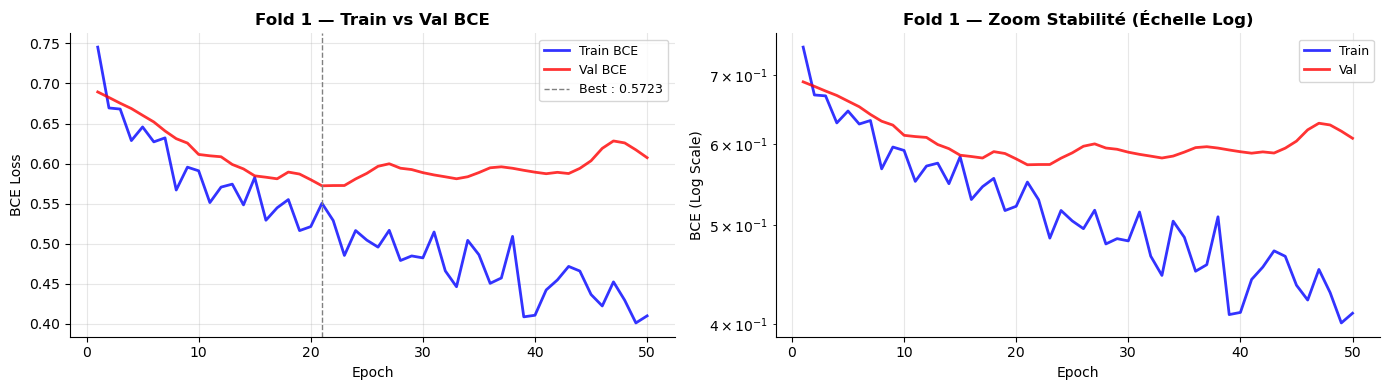


📊 MÉTRIQUES FINALES PAR FOLD (CLASSIFICATION)
   Fold 01 — Meilleure Val BCE : 0.5723


In [66]:
# On récupère le nombre réel de folds entraînés avec succès
n_effective_folds = len(all_results)

# On crée une grille : n_effective_folds lignes, 2 colonnes (BCE et Accuracy)
fig, axes = plt.subplots(n_effective_folds, 2, figsize=(14, 4 * n_effective_folds))

# Sécurité si all_results ne contient qu'un seul fold (pour que axes reste une matrice 2D)
if n_effective_folds == 1:
    axes = np.expand_dims(axes, axis=0)

for fold_idx, fold_data in enumerate(all_results):
    results_f = fold_data["results"]
    epochs    = range(1, len(results_f['train_losses']) + 1)

    # 📈 1ère colonne : Courbe BCE
    ax1 = axes[fold_idx, 0]
    ax1.plot(epochs, results_f['train_losses'], 'b-', linewidth=2, label='Train BCE', alpha=0.8)
    ax1.plot(epochs, results_f['val_losses'],   'r-', linewidth=2, label='Val BCE',   alpha=0.8)
    ax1.axvline(x=results_f['val_losses'].index(results_f['best_val_loss']) + 1,
                color='gray', linestyle='--', linewidth=1,
                label=f"Best : {results_f['best_val_loss']:.4f}")
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('BCE Loss')
    ax1.set_title(f'Fold {fold_data["fold"]} — Train vs Val BCE', fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # 🎯 2ème colonne : Évolution des pertes zoomée ou autre métrique
    # (Puisque le RMSE de la BCE n'existe pas, on affiche ici les pertes en échelle logarithmique 
    # pour mieux détecter l'overfitting, ou vous pouvez y tracker l'accuracy si vous l'ajoutez à votre historique)
    ax2 = axes[fold_idx, 1]
    ax2.plot(epochs, results_f['train_losses'], 'b-', linewidth=2, label='Train', alpha=0.8)
    ax2.plot(epochs, results_f['val_losses'],   'r-', linewidth=2, label='Val',   alpha=0.8)
    ax2.set_yscale('log') # Échelle logarithmique pour inspecter la stabilité numérique
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('BCE (Log Scale)')
    ax2.set_title(f'Fold {fold_data["fold"]} — Zoom Stabilité (Échelle Log)', fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# --- Affichage des métriques finales épurées ---
print("\n📊 MÉTRIQUES FINALES PAR FOLD (CLASSIFICATION)")
print("=" * 50)
for fold_data in all_results:
    r = fold_data["results"]
    print(f"   Fold {fold_data['fold']:02d} — Meilleure Val BCE : {r['best_val_loss']:.4f}")

In [67]:
print("📊 ÉVALUATION GLOBALE (CUMULÉE) PAR FOLD")
print("=" * 60)

all_val_preds = []
all_val_trues = []  # ← une seule liste, nom cohérent

for fold_data in all_results:
    model_f  = fold_data["results"]["model"]
    fold_idx = fold_data["fold"] - 1

    X_val_raw    = x_vals[fold_idx]
    y_val_f      = y_vals[fold_idx]
    val_nan_mask = torch.isnan(X_val_raw).any(dim=1)
    X_val_clean  = X_val_raw[~val_nan_mask]
    y_val_clean  = y_val_f[~val_nan_mask]

    if len(X_val_clean) == 0:
        continue

    X_val_cont_scaled = fold_data["scaler"].transform(X_val_clean[:, :n_continuous].numpy())
    X_val_tensor_f    = torch.tensor(
        np.concatenate([X_val_cont_scaled, X_val_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )

    model_f.eval()
    with torch.no_grad():
        logits = model_f(X_val_tensor_f.to(device)).squeeze(-1)
        if logits.dim() == 0:
            logits = logits.unsqueeze(0)
        val_preds = torch.sigmoid(logits).cpu().numpy()

    val_true = y_val_clean.numpy()

    all_val_preds.extend(val_preds)
    all_val_trues.extend(val_true)  # ← plus de all_val_labels

    bce_locale = log_loss(val_true, val_preds, labels=[0, 1])
    print(f"   Fold {fold_data['fold']:02d} ({len(val_true):02d} cellules) — BCE locale : {bce_locale:.4f}")

# --- MÉTRIQUES GLOBALES ---
print("\n" + "="*60)
print("📈 PERFORMANCE FINALE DU SYSTÈME SPATIAL (LOO)")
print("="*60)

y_pred_all   = np.array(all_val_preds)
y_true_all   = np.array(all_val_trues)  # ← cohérent
y_pred_class = (y_pred_all >= 0.5).astype(int)

unique, counts = np.unique(y_true_all, return_counts=True)
print(f"Labels dans y_true_all : {dict(zip(unique, counts))}")

global_bce = log_loss(y_true_all, y_pred_all, labels=[0, 1])

if len(np.unique(y_true_all)) > 1:
    global_auc = roc_auc_score(y_true_all, y_pred_all)
else:
    global_auc = float('nan')
    print("⚠️ AUC indéfinie : y_true_all ne contient qu'une seule classe")

global_acc = accuracy_score(y_true_all, y_pred_class)

print(f"   Nombre total de cellules validées : {len(y_true_all)}")
print(f"   BCE Globale      : {global_bce:.4f}")
print(f"   AUC-ROC Globale  : {global_auc:.4f}  (Capacité de discrimination)")
print(f"   Accuracy Globale : {global_acc:.4f}  (Taux de bonne classification)")

📊 ÉVALUATION GLOBALE (CUMULÉE) PAR FOLD
   Fold 01 (36 cellules) — BCE locale : 0.5723

📈 PERFORMANCE FINALE DU SYSTÈME SPATIAL (LOO)
Labels dans y_true_all : {np.float32(0.0): np.int64(17), np.float32(1.0): np.int64(19)}
   Nombre total de cellules validées : 36
   BCE Globale      : 0.5723
   AUC-ROC Globale  : 0.7709  (Capacité de discrimination)
   Accuracy Globale : 0.6944  (Taux de bonne classification)


In [68]:
# 1. Récupération robuste du meilleur fold basé sur vos résultats effectifs
best_fold_id = best_fold["fold"]
# On cherche l'index correspondant dans votre liste de départ (au cas où des folds manquent)
best_fold_idx = best_fold_id - 1 

y_train_best = y_trains[best_fold_idx]
X_train_best = x_trains[best_fold_idx]

print(f"📊 Corrélations covariables → iG-APEX binaire (train fold {best_fold_id}) :")
print("=" * 65)

# Nettoyage des noms de fichiers de vos rasters
var_names_clean = [
    f.replace('data/cov/rasters/', '')
     .replace('alt/', '').replace('cwb/', '').replace('ru/', '')
     .replace('.tif', '')
    for f in raster_files[:n_continuous]  # toutes les continues
]

# --- Partie 1 : Covariables continues ---
for i, name in enumerate(var_names_clean):
    x_col = X_train_best[:, i]
    y_col = y_train_best
    
    # ⚠️ SÉCURITÉ CRITIQUE : Le masque doit filtrer les NaNs de X ET s'assurer de l'alignement avec Y
    # On crée un masque combiné pour éliminer les lignes contenant un NaN dans l'une ou l'autre variable
    mask = ~torch.isnan(x_col) & ~torch.isnan(y_col)
    
    # Si le masque élimine tout ou s'il n'y a pas assez de données pour une corrélation
    if mask.sum() < 2:
        print(f"   {name:40s} r = NaN (Données insuffisantes)")
        continue
        
    corr = np.corrcoef(x_col[mask].numpy(), y_col[mask].numpy())[0, 1]
    print(f"   {name:40s} r = {corr:.3f}")

# --- Partie 2 : Corrélations RU (one-hot) ---
print(f"\n📊 Corrélations RU (one-hot) → iG-APEX binaire (train fold {best_fold_id}) :")
print("=" * 65)

for j, cls in enumerate(ru_classes):
    x_col = X_train_best[:, n_continuous + j]
    y_col = y_train_best
    
    # Même masque de sécurité combiné pour le One-Hot encoding
    mask = ~torch.isnan(x_col) & ~torch.isnan(y_col)
    
    if mask.sum() < 2:
        print(f"   RU classe {cls:<2} r = NaN")
        continue
        
    corr = np.corrcoef(x_col[mask].numpy(), y_col[mask].numpy())[0, 1]
    
    # Formattage propre des libellés (conforme à vos nouvelles classes du rouge au bleu)
    label = f"RU classe {cls}"
    if cls == 9:
        label += " (non-sol)"
    elif cls == 1:
        label += " (< 50mm)"
    elif cls == 2:
        label += " (50-100mm)"
    elif cls == 3:
        label += " (100-150mm)"
    elif cls == 4:
        label += " (150-200mm)"
    elif cls == 5:
        label += " (>= 200mm)"
        
    print(f"   {label:35s} r = {corr:.3f}")

# --- Partie 3 : Corrélations SICLIMA ---
print(f"\n📊 Corrélations SICLIMA → iG-APEX binaire (train fold {best_fold_id}) :")
print("=" * 65)

siclima_start = n_continuous - len(COVARIABLES)  # = 20 - 16 = 4

for j, cov_name in enumerate(COVARIABLES):
    x_col = X_train_best[:, siclima_start + j]
    y_col = y_train_best

    mask = ~torch.isnan(x_col) & ~torch.isnan(y_col)

    if mask.sum() < 2:
        print(f"   {cov_name:40s} r = NaN (Données insuffisantes)")
        continue

    corr = np.corrcoef(x_col[mask].numpy(), y_col[mask].numpy())[0, 1]
    print(f"   {cov_name:40s} r = {corr:.3f}")

📊 Corrélations covariables → iG-APEX binaire (train fold 1) :
   alt\altitude_study_zone                  r = -0.030
   ru\ru_raster                             r = 0.037
   pente\slope                              r = 0.075
   exp\exposure                             r = -0.046
   CWB_1km_2025-07-13                       r = 0.130

📊 Corrélations RU (one-hot) → iG-APEX binaire (train fold 1) :
   RU classe 1 (< 50mm)                r = -0.058
   RU classe 2 (50-100mm)              r = -0.018
   RU classe 3 (100-150mm)             r = 0.116
   RU classe 4 (150-200mm)             r = 0.012
   RU classe 5 (>= 200mm)              r = nan
   RU classe 9 (non-sol)               r = nan

📊 Corrélations SICLIMA → iG-APEX binaire (train fold 1) :
   dli_q                                    r = 0.130
   t_q                                      r = 0.093
   co2                                      r = nan
   drainc_q                                 r = -0.158
   pe_q                             

## 10. GENERATE IG-APEX MAP

In [69]:
# ==============================================================================
#  ÉTAPES COMPLÈTES : PRÉDICTION SUR TOUTE LA GRILLE VIA LE MEILLEUR FOLD
# ==============================================================================

# 1. Sélection automatique du meilleur Fold entraîné
best_fold_idx = np.argmin([r["val_loss"] for r in all_results])
best_fold = all_results[best_fold_idx]

model = best_fold["results"]["model"]
scaler_grid = best_fold["scaler"]

print(f"✅ Modèle et Scaler extraits avec succès depuis le Fold {best_fold['fold']}")

# 2. Masquage de sécurité pour les NaNs globaux (cellules hors-zone ou sans data)
# X_tensor contient déjà TOUTES les features de ta grille (créé en cellules 22-23)
valid_grid_mask = ~torch.isnan(X_tensor).any(dim=1)

# Extraction des lignes valides uniquement
X_grid_clean = X_tensor[valid_grid_mask]

# 3. Normalisation rigoureuse (uniquement sur les variables continues)
X_grid_cont_scaled = scaler_grid.transform(X_grid_clean[:, :n_continuous].numpy())

# Re-combinaison avec les variables catégorielles (RU one-hot)
X_grid_combined = np.concatenate([X_grid_cont_scaled, X_grid_clean[:, n_continuous:].numpy()], axis=1)
X_grid_final_tensor = torch.tensor(X_grid_combined, dtype=torch.float32)

print(f"📊 Nombre total de cellules dans la grille : {len(X_tensor):,}")
print(f"🎯 Cellules valides prêtes pour l'inférence : {len(X_grid_final_tensor):,}")

# 4. Inférence Spatiale avec Monte Carlo Dropout
print("🚀 Calcul des prédictions et de l'incertitude (MC-Dropout)...")
mean_pred_valid, std_pred_valid = predict_with_uncertainty(
    model=model, 
    X_tensor=X_grid_final_tensor, 
    device=device, 
    n_samples=100
)

# 5. Reconstruction des tenseurs complets pour correspondre à la taille de la grille
# On initialise avec des NaNs pour que les mailles sans données ne soient pas tracées
pred_mean_full = torch.full((len(X_tensor),), float('nan'), dtype=torch.float32)
pred_std_full  = torch.full((len(X_tensor),), float('nan'), dtype=torch.float32)

# On réinjecte nos prédictions aux bons indices valides
pred_mean_full[valid_grid_mask] = mean_pred_valid
pred_std_full[valid_grid_mask]  = std_pred_valid

print("🎉 Terminé ! Les variables 'pred_mean_full' et 'pred_std_full' sont prêtes.")

✅ Modèle et Scaler extraits avec succès depuis le Fold 1
📊 Nombre total de cellules dans la grille : 36,377
🎯 Cellules valides prêtes pour l'inférence : 33,473
🚀 Calcul des prédictions et de l'incertitude (MC-Dropout)...
🎉 Terminé ! Les variables 'pred_mean_full' et 'pred_std_full' sont prêtes.


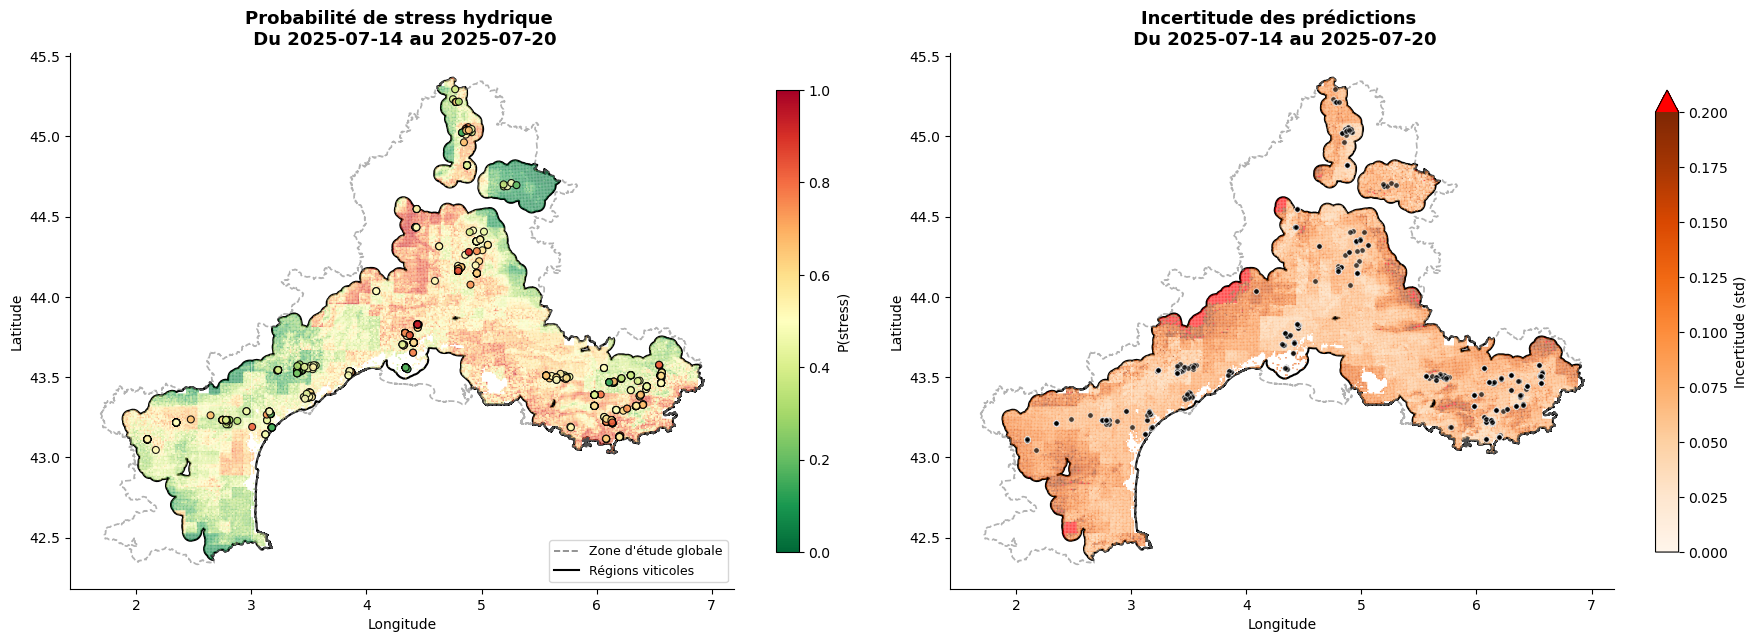

In [70]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# --- 1. [Calcul de la probabilité de stress : 1 - p] ---
pred_stress_full = 1.0 - pred_mean_full

# Attribution des résultats à notre GeoDataFrame de la grille
grid_pred = grid_wgs84.copy()
grid_pred['proba_stress'] = pred_stress_full.numpy()
grid_pred['uncertainty']  = pred_std_full.numpy()

# Préparation de la variable terrain (on crée les objets géo une seule fois)
study_zone_wgs    = study_zone.to_crs("EPSG:4326")
study_zone_bg_wgs = study_zone_bg.to_crs("EPSG:4326")
data_zone_wgs     = data_zone.to_crs("EPSG:4326").copy()

# Calcul de la probabilité terrain inversée (1 = Stress, 0 = Non-stress)
data_zone_wgs['proba_stress'] = 1.0 - data_zone_wgs['ic_apex']


# --- 2. Génération de la double carte (Prédiction + Incertitude MC-Dropout) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Carte 1 : Probabilités de Stress ---
ax1 = axes[0]

# Tracé des contours de la zone d'étude (principal + arrière-plan en pointillés)
study_zone_wgs.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=1.5)
study_zone_bg_wgs.plot(ax=ax1, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)

# Affichage de la grille prédictive (Modifié : 'RdYlGn_r' pour avoir le stress en rouge)
grid_pred.dropna(subset=['proba_stress']).plot(
    ax=ax1, column='proba_stress', cmap='RdYlGn_r',
    legend=True, alpha=0.7,
    legend_kwds={'label': 'P(stress)', 'shrink': 0.6},
    vmin=0, vmax=1
)

# Points terrain observés superposés
data_zone_wgs.plot(
    ax=ax1, column='proba_stress', cmap='RdYlGn_r',
    markersize=25, edgecolor='black', linewidth=0.8,
    alpha=0.9, legend=False, vmin=0, vmax=1
)
ax1.set_title(f'Probabilité de stress hydrique \n Du {date_debut_str} au {date_fin_str}', fontsize=13, fontweight='bold')

# Ne pas oublier de définir 'legend_elements' en amont si vous utilisez cette ligne :
if 'legend_elements' in locals() or 'legend_elements' in globals():
    ax1.legend(handles=legend_elements, fontsize=9, loc="lower right")


# --- Carte 2 : Carte d'Incertitude Spatiale ---
ax2 = axes[1]
study_zone_wgs.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=1.5)
study_zone_bg_wgs.plot(ax=ax2, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)

# 1. Récupération de la palette Oranges existante
cmap_incertitude = plt.colormaps['Oranges'].copy()

# 2. On force la couleur des valeurs "Over" (au-delà de vmax) en rouge
cmap_incertitude.set_over('red')

# 3. Tracé de la grille avec une échelle bloquée entre 0 et 0.2
grid_pred.dropna(subset=['uncertainty']).plot(
    ax=ax2, 
    column='uncertainty', 
    cmap=cmap_incertitude,
    legend=True, 
    alpha=0.7,
    vmin=0.0, 
    vmax=0.2,  # <-- Bloque le haut de l'échelle à 0.2
    legend_kwds={
        'label': 'Incertitude (std)', 
        'shrink': 0.6,
        'extend': 'max'  # <-- Ajoute une flèche triangulaire rouge en haut de la colorbar
    }
)

# Points terrain en noir pour le contraste sur l'incertitude
data_zone_wgs.plot(
    ax=ax2, color='black',
    markersize=15, edgecolor='white', linewidth=0.5,
    alpha=0.7, legend=False
)
ax2.set_title(f'Incertitude des prédictions \n Du {date_debut_str} au {date_fin_str}', fontsize=13, fontweight='bold')


# --- 3. Finitions esthétiques des axes ---
for ax in axes:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

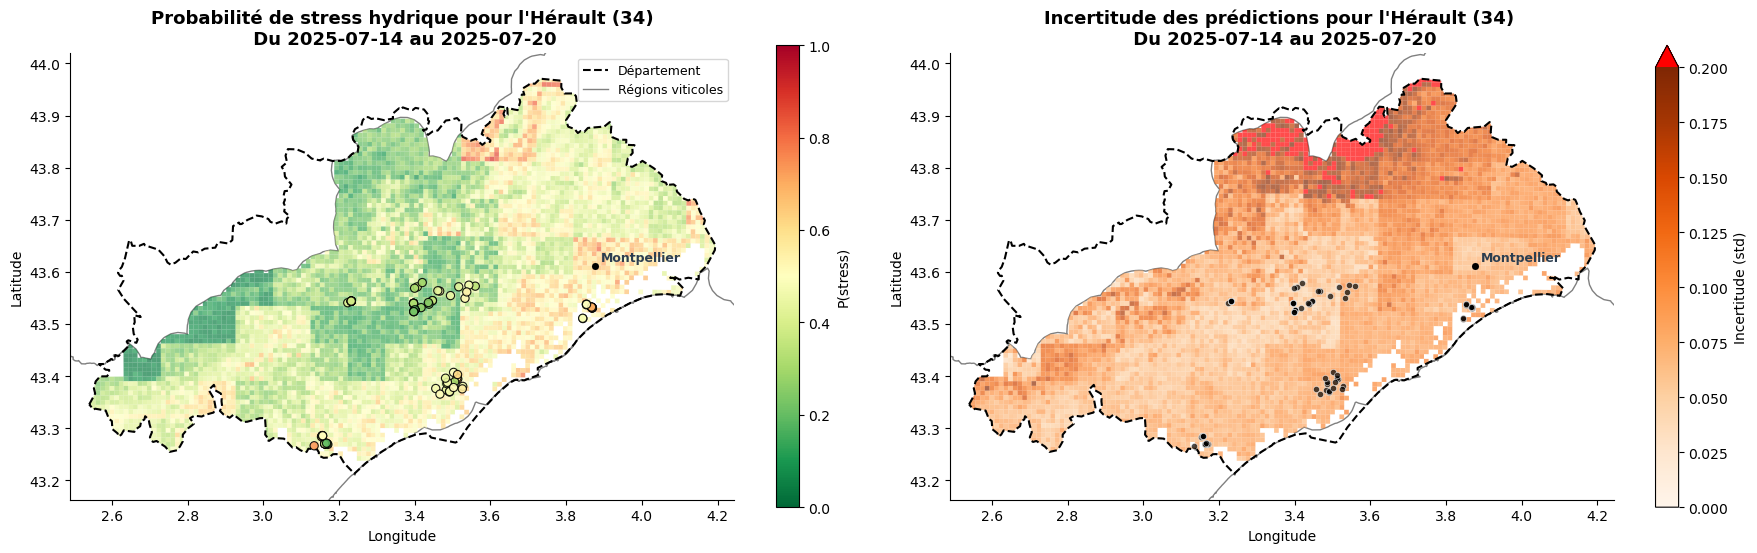

In [71]:
code_dept_param = "34" 

# Chargement et projection des départements en WGS84
gdf_departements = gpd.read_file("data/contours_dpt.gpkg")
gdf_deps_wgs84 = gdf_departements.to_crs("EPSG:4326")

# Extraction du contour du département ciblé
dept_cible = gdf_deps_wgs84[gdf_deps_wgs84["DDEP_C_COD"] == code_dept_param]

if dept_cible.empty:
    raise ValueError(f"Le département {code_dept_param} n'a pas été trouvé.")

dept_nom = gdf_deps_wgs84.loc[gdf_deps_wgs84["DDEP_C_COD"] == code_dept_param, 'DDEP_L_LIB'].values[0]
if code_dept_param in ["07","11","34"]:
    dept_prep = "l'"
elif code_dept_param in ["30", "83", "84"]:
    dept_prep = "le "
elif code_dept_param in ["13", "66"]:
    dept_prep = "les "
else:
    dept_prep = "la "

# Récupération de la préfecture du département ciblé
ville_dept = villes_gdf[villes_gdf['Code_insee'] == code_dept_param]

# 🛠️ ASTUCE : On isole uniquement la géométrie du département pour éviter les conflits de colonnes
dept_geom_only = dept_cible[['geometry']]

# ✂️ Découpe spatiale propre sans modification de tes colonnes
grid_pred_clipped = gpd.overlay(grid_pred, dept_geom_only, how='intersection')
data_zone_clipped = gpd.overlay(data_zone_wgs, dept_geom_only, how='intersection')
data_zone_clipped['proba_stress'] = 1.0 - data_zone_clipped['ic_apex']

# ==========================================
# 2. GÉNÉRATION DE LA DOUBLE CARTE ZOOMÉE
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Carte 1 : Probabilités de Stress ---
ax1 = axes[0]

# Arrière-plan global
study_zone_wgs.plot(ax=ax1, facecolor='none', edgecolor='grey', linewidth=1)
# Limite du département en pointillé noir
dept_cible.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=1.5, linestyle='--', zorder=3)

# Préfecture
if not ville_dept.empty:
    ville_dept.plot(ax=ax1, color='black', markersize=100, marker='.', 
                    edgecolor='black', linewidth=0.1, zorder=5)
    
    for x, y, label in zip(ville_dept.geometry.x, ville_dept.geometry.y, ville_dept['Nom']):
        ax1.annotate(label, xy=(x, y), xytext=(4, 4),
                    textcoords='offset points', fontsize=9,
                    fontweight='bold', color='#2c3e50')

# Grille prédictive coupée
if not grid_pred_clipped.empty:
    grid_pred_clipped.dropna(subset=['proba_stress']).plot(
        ax=ax1, column='proba_stress', cmap='RdYlGn_r',
        legend=True, alpha=0.7,
        legend_kwds={'label': 'P(stress)', 'shrink': 0.6},
        vmin=0, vmax=1
    )

# Points terrain observés coupés
if not data_zone_clipped.empty:
    data_zone_clipped.plot(
        ax=ax1, column='proba_stress', cmap='RdYlGn_r',
        markersize=35, edgecolor='black', linewidth=0.8,
        alpha=0.9, legend=False, vmin=0, vmax=1, zorder=4
    )

ax1.set_title(f'Probabilité de stress hydrique pour {dept_prep}{dept_nom} ({code_dept_param})\n Du {date_debut_str} au {date_fin_str}', fontsize=13, fontweight='bold')


# Légende commune
legend_dpts = [Line2D([0],[0],color="black",linewidth=1.5,linestyle="--",label="Département"),
                   Line2D([0],[0],color="grey",linewidth=1,linestyle="-",label="Régions viticoles")]

ax1.legend(handles=legend_dpts, fontsize=9, loc="upper right")


# --- Carte 2 : Carte d'Incertitude Spatiale ---
ax2 = axes[1]

# Arrière-plan global
study_zone_wgs.plot(ax=ax2, facecolor='none', edgecolor='grey', linewidth=1)
# Limite du département en pointillé noir
dept_cible.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=1.5, linestyle='--', zorder=3)

# Préfecture
if not ville_dept.empty:
    ville_dept.plot(ax=ax2, color='black', markersize=100, marker='.', 
                    edgecolor='black', linewidth=0.1, zorder=5)
    
    for x, y, label in zip(ville_dept.geometry.x, ville_dept.geometry.y, ville_dept['Nom']):
        ax2.annotate(label, xy=(x, y), xytext=(4, 4),
                    textcoords='offset points', fontsize=9,
                    fontweight='bold', color='#2c3e50')


# Palette Incertitude (réutilisation de la configuration du premier chunk)
cmap_incertitude = plt.colormaps['Oranges'].copy()
cmap_incertitude.set_over('red')

# Grille d'incertitude coupée
if not grid_pred_clipped.empty:
    grid_pred_clipped.dropna(subset=['uncertainty']).plot(
        ax=ax2, 
        column='uncertainty', 
        cmap=cmap_incertitude,
        legend=True, 
        alpha=0.7,
        vmin=0.0, 
        vmax=0.2, 
        legend_kwds={
            'label': 'Incertitude (std)', 
            'shrink': 0.6,
            'extend': 'max'
        }
    )

# Points terrain coupés en noir
if not data_zone_clipped.empty:
    data_zone_clipped.plot(
        ax=ax2, color='black',
        markersize=20, edgecolor='white', linewidth=0.5,
        alpha=0.7, legend=False, zorder=4
    )

ax2.set_title(f'Incertitude des prédictions pour {dept_prep}{dept_nom} ({code_dept_param}) \n Du {date_debut_str} au {date_fin_str}', fontsize=13, fontweight='bold')


# --- 3. Ajustement des axes et zoom sur le département ---
for ax in axes:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Cadrage dynamique sur le département (+ marge de 0.05 degré)
    bounds = dept_cible.total_bounds
    ax.set_xlim(bounds[0] - 0.05, bounds[2] + 0.05)
    ax.set_ylim(bounds[1] - 0.05, bounds[3] + 0.05)

plt.tight_layout()
plt.show()